# Graph structure

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations
"""
k-local unlabeled graph generator with robust canonicalization for ALL degrees,
degree filter (== or ≤), full plotting utilities, configurable canon_method,
and backward-compatible 2-local multiedge plotting.

New in this version:
  • components constraint: store only graphs with exactly c connected components.
    Use components=None to disable. When enumerating, we prune via rollback-DSU.

Additions from earlier:
  • locality (k) >= 2: enumerate k-local blocks on all k-subsets.
  • For locality==2, behavior identical to previous version (including pair_mats).
  • For locality>2, store k-local assignment; pair_mats omitted (plotting still
    available for earlier 2-local runs; multiedge plot needs pair_mats from 2-local).

Requirements:
    pip install python-igraph tqdm networkx matplotlib numpy
"""

import os, gzip, random, math, sys, itertools, json, ast
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple
from collections import defaultdict

import numpy as np
from numpy.typing import NDArray
import networkx as nx
import igraph as ig
from functools import lru_cache

try:
    from tqdm import tqdm  # type: ignore
    _HAVE_TQDM = True
except Exception:
    _HAVE_TQDM = False

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle


# ---------------------------------------------------------------------------
#  Helpers
# ---------------------------------------------------------------------------

def iter_pairs(n: int) -> List[Tuple[int,int]]:
    return [(i,j) for i in range(n) for j in range(i+1,n)]

def iter_k_subsets(n: int, k: int) -> List[Tuple[int,...]]:
    return list(itertools.combinations(range(n), k))

def _upper_tri_edges(N: int) -> List[Tuple[int,int]]:
    return [(i,j) for i in range(N) for j in range(i+1,N)]

def bits_tuple_to_hex(bits: Tuple[int, ...]) -> str:
    val = 0
    for b in bits:
        val = (val << 1) | (1 if b else 0)
    hexlen = max(1, math.ceil(len(bits) / 4))
    return f"{val:0{hexlen}x}"

def hex_to_bits_tuple(hex_str: str, num_bits: int) -> Tuple[int, ...]:
    val = int(hex_str, 16)
    return tuple(((val >> k) & 1) for k in reversed(range(num_bits)))

def bits_to_graph(bits: Tuple[int, ...], N: int) -> nx.Graph:
    G = nx.Graph()
    G.add_nodes_from(range(N))
    idx = 0
    for i in range(N):
        for j in range(i+1, N):
            if bits[idx] == 1:
                G.add_edge(i, j)
            idx += 1
    return G

def _upper_tri_bits_for_order(edges_set: Set[Tuple[int,int]], order: List[int]) -> Tuple[int, ...]:
    bits: List[int] = []
    n = len(order)
    for i in range(n):
        vi = order[i]
        for j in range(i+1, n):
            vj = order[j]
            e = (vi, vj) if vi < vj else (vj, vi)
            bits.append(1 if e in edges_set else 0)
    return tuple(bits)

def _graph_edgeset(G: nx.Graph) -> Set[Tuple[int,int]]:
    return set((min(u,v), max(u,v)) for u,v in G.edges())

def _print_prog(msg: str):
    print(msg, flush=True, file=sys.stderr)


# ---------------------------------------------------------------------------
#  Rollback DSU (Union-Find with undo) for connectivity pruning
# ---------------------------------------------------------------------------

class DSU:
    __slots__ = ("parent","rank","cc","stack")
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0]*n
        self.cc = n
        self.stack: List[Tuple[int,int,int,bool]] = []  # (child, old_parent, old_cc, rank_inc)
    def find(self, a: int) -> int:
        while self.parent[a] != a:
            a = self.parent[a]
        return a
    def union(self, a: int, b: int) -> bool:
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            self.stack.append((-1,-1,self.cc, False))
            return False
        # union by rank
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.stack.append((rb, self.parent[rb], self.cc, self.rank[ra] == self.rank[rb]))
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
            rank_inc = True
        else:
            rank_inc = False
        self.cc -= 1
        # adjust last tuple (store whether rank increased)
        self.stack[-1] = (self.stack[-1][0], self.stack[-1][1], self.stack[-1][2], rank_inc)
        return True
    def snapshot(self) -> int:
        return len(self.stack)
    def rollback(self, snap: int) -> None:
        while len(self.stack) > snap:
            child, old_parent, old_cc, rank_inc = self.stack.pop()
            if child != -1:
                root = self.parent[child]
                self.parent[child] = old_parent
                if rank_inc:
                    self.rank[root] -= 1
            self.cc = old_cc

# ---------------------------------------------------------------------------
#  Canonicalization backends — EXACT & DETERMINISTIC (drop-in replacement)
# ---------------------------------------------------------------------------

from typing import Dict, List, Tuple, Optional
import networkx as nx

# Optional: turn on to belt-and-suspenders check a few representatives (slow).
CANON_VERIFY_VF2 = False

# ---------- helpers shared by exact WL+IR ----------
def _wl_refine_colors(G: nx.Graph, colors: List[int]) -> List[int]:
    n = G.number_of_nodes()
    adj = {u: list(G.neighbors(u)) for u in range(n)}
    cur = colors[:]
    while True:
        sigs = []
        for u in range(n):
            neigh_sig = tuple(sorted(cur[v] for v in adj[u]))
            sigs.append((cur[u], neigh_sig))
        uniq: Dict[Tuple[int, Tuple[int, ...]], int] = {}
        nxt = [0] * n
        for u, s in enumerate(sigs):
            if s not in uniq:
                uniq[s] = len(uniq)
            nxt[u] = uniq[s]
        if nxt == cur:
            break
        cur = nxt
    # compact IDs 0..k-1
    remap: Dict[int, int] = {}
    out = [0]*n
    k = 0
    for u in range(n):
        c = cur[u]
        if c not in remap:
            remap[c] = k; k += 1
        out[u] = remap[c]
    return out

def _order_from_colors(colors: List[int]) -> List[int]:
    classes: Dict[int, List[int]] = {}
    for v, c in enumerate(colors):
        classes.setdefault(c, []).append(v)
    order: List[int] = []
    for c in sorted(classes):
        order.extend(sorted(classes[c]))
    return order

def _permute_graph_g6(G: nx.Graph, order: List[int]) -> str:
    rel = {order[i]: i for i in range(len(order))}
    H = nx.relabel_nodes(G, rel, copy=True)
    return nx.to_graph6_bytes(H, header=False).decode("ascii")

# ---------- trivial graph fast paths (exact) ----------
def _is_complete(G: nx.Graph) -> bool:
    n = G.number_of_nodes()
    return G.number_of_edges() == n*(n-1)//2

def _is_empty(G: nx.Graph) -> bool:
    return G.number_of_edges() == 0

def _canon_key_trivial_g6(G: nx.Graph) -> Optional[Tuple[str, List[int], str]]:
    n = G.number_of_nodes()
    if _is_empty(G):
        H = nx.empty_graph(n)
        g6 = nx.to_graph6_bytes(H, header=False).decode("ascii")
        return g6, list(range(n)), "trivial(empty)"
    if _is_complete(G):
        H = nx.complete_graph(n)
        g6 = nx.to_graph6_bytes(H, header=False).decode("ascii")
        return g6, list(range(n)), "trivial(complete)"
    return None

# ---------- exact structural canon for deg ≤ 2 (paths/cycles) ----------
def _canon_key_for_deg_le2_structural(G: nx.Graph) -> Tuple[str, List[int]]:
    N = G.number_of_nodes()
    comps = [G.subgraph(c).copy() for c in nx.connected_components(G)]
    types: List[Tuple[str,int]] = []
    for H in comps:
        L = H.number_of_nodes()
        if L <= 1:
            types.append(("P",1)); continue
        d = dict(H.degree())
        if min(d.values()) == 2 and max(d.values()) == 2 and H.number_of_edges() == L:
            types.append(("C",L))
        else:
            types.append(("P",L))
    from collections import Counter
    cnt = Counter(types)
    Hcanon = nx.Graph(); Hcanon.add_nodes_from(range(N))
    cursor = 0
    for (t,L), m in sorted(cnt.items(), key=lambda kv: (kv[0][0], kv[0][1])):  # ('C'<'P'), then size
        for _ in range(m):
            if L <= 1:
                cursor += L; continue
            for a in range(L-1):
                Hcanon.add_edge(cursor+a, cursor+a+1)
            if t == "C":
                Hcanon.add_edge(cursor, cursor+L-1)
            cursor += L
    assert cursor == N
    g6 = nx.to_graph6_bytes(Hcanon, header=False).decode("ascii")
    return g6, list(range(N))

# ---------- exact canonicalization via nauty/Traces (pynauty) ----------
def _canon_key_traces_g6(G: nx.Graph) -> Tuple[str, List[int], str]:
    """
    Exact, deterministic canonical labeling using nauty/Traces via pynauty.
    Returns a graph6 key and the canonical vertex order.
    """
    try:
        import pynauty as nauty
    except Exception as e:
        raise RuntimeError("pynauty (nauty/Traces) not installed; run `pip install pynauty`") from e

    n = G.number_of_nodes()
    if sorted(G.nodes()) != list(range(n)):
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    # degree partition helps Traces; safe for exact canon
    degs = [G.degree(u) for u in range(n)]
    part_dict: Dict[int, List[int]] = {}
    for v, d in enumerate(degs):
        part_dict.setdefault(d, []).append(v)
    partition = [sorted(cls) for _, cls in sorted(part_dict.items())]

    ng = nauty.Graph(number_of_vertices=n, directed=False)
    for u in range(n):
        ng.connect_vertex(u, sorted(G.neighbors(u)))
    if len(partition) > 1:
        ng.set_partition(partition)

    perm = nauty.canon_label(ng)     # tuple old->canon position
    rel = {int(perm[i]): i for i in range(n)}  # place vertex perm[i] at i
    H = nx.relabel_nodes(G, rel, copy=True)
    g6 = nx.to_graph6_bytes(H, header=False).decode("ascii")
    return g6, list(map(int, perm)), "traces+g6"

# ---------- exact WL+IR fallback (individualize–refine; exponential worst-case) ----------
def _canon_key_wlir_g6_exact(G: nx.Graph) -> Tuple[str, List[int], str]:
    n = G.number_of_nodes()
    if sorted(G.nodes()) != list(range(n)):
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    base_colors = [G.degree(v) for v in range(n)]
    colors = _wl_refine_colors(G, base_colors)
    best_order = _order_from_colors(colors)
    best_key = _permute_graph_g6(G, best_order)
    if len(set(colors)) == n:
        return best_key, best_order, "wlir_exact(discrete)"

    from collections import defaultdict
    def cells_from_colors(cols: List[int]) -> List[List[int]]:
        d: Dict[int, List[int]] = defaultdict(list)
        for v, c in enumerate(cols):
            d[c].append(v)
        return [sorted(cell) for _, cell in sorted(d.items())]

    def refine(cols: List[int]) -> Tuple[List[int], str]:
        c2 = _wl_refine_colors(G, cols)
        ord2 = _order_from_colors(c2)
        key2 = _permute_graph_g6(G, ord2)
        return c2, key2

    def choose_cell(cols: List[int]) -> Optional[List[int]]:
        cells = [cell for cell in cells_from_colors(cols) if len(cell) > 1]
        if not cells:
            return None
        # heuristic: largest non-singleton first, then by min id
        cells.sort(key=lambda L: (-len(L), L[0]))
        return cells[0]

    visited_bounds = set()
    def dfs(cols: List[int]):
        nonlocal best_key
        # bounding by current refined key
        _, bound_key = refine(cols)
        if bound_key >= best_key:
            return
        cell = choose_cell(cols)
        if cell is None:
            # fully discrete
            order = _order_from_colors(cols)
            key = _permute_graph_g6(G, order)
            if key < best_key:
                best_key = key
            return
        # branch: individualize each vertex in the chosen cell
        for v in cell:
            new_cols = cols[:]
            new_cols[v] = max(new_cols) + 1
            # cache by tuple to avoid identical subproblems
            t = tuple(new_cols)
            if t in visited_bounds:
                continue
            visited_bounds.add(t)
            dfs(new_cols)

    dfs(colors)
    return best_key, best_order, "wlir_exact"

# ---------- public selector: exact & deterministic ----------
def _canon_auto_with_backends(
    G: nx.Graph,
    canon_method: str,
    *,
    full_perm_nmax_exact: int,  # unused; kept for signature compatibility
    perm_sample: int,           # unused; kept for signature compatibility
    perm_seed: Optional[int]    # unused; kept for signature compatibility
) -> Tuple[str, str]:
    """
    Exact canonicalization pipeline (no randomness):
      • trivial empty/complete → graph6
      • deg ≤ 2 → exact structural path/cycle → graph6
      • else try nauty/Traces via pynauty → graph6
      • fallback to exact WL+IR (individualize–refine) → graph6
    The returned key is a deterministic canonical representative; use it for dedup.
    """
    n = G.number_of_nodes()
    if sorted(G.nodes()) != list(range(n)):
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    # trivial fast paths
    t = _canon_key_trivial_g6(G)
    if t is not None:
        key, _, mode = t
        return key, mode

    # deg ≤ 2 structural exact canon
    maxdeg = max((d for _, d in G.degree()), default=0)
    if (canon_method or "auto").lower() in ("deg_le2_exact",) or maxdeg <= 2:
        key, _ = _canon_key_for_deg_le2_structural(G)
        return key, "deg_le2_struct+g6"

    # exact nauty/Traces if available
    try:
        key, _, mode = _canon_key_traces_g6(G)
        return key, mode
    except Exception:
        # exact WL+IR fallback (may be slow on highly symmetric families)
        key, _, mode = _canon_key_wlir_g6_exact(G)
        return key, mode

# ---------- optional verification harness ----------
class _IsoVerifier:
    def __init__(self):
        self.repr_by_key: Dict[str, nx.Graph] = {}
    def check_or_add(self, key: str, G: nx.Graph) -> bool:
        if not CANON_VERIFY_VF2:
            return True
        rep = self.repr_by_key.get(key)
        if rep is None:
            self.repr_by_key[key] = G.copy()
            return True
        if not nx.is_isomorphic(rep, G):
            raise RuntimeError("Canonical key collision detected (should never happen).")
        return True

_CANON_VERIFIER = _IsoVerifier()

# ---------------------------------------------------------------------------
#  Fast global graph building (2-local base)
# ---------------------------------------------------------------------------

_OFFDIAG_PAIRS_4 = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

def _block4_from_bits(bits6: int) -> NDArray[np.uint8]:
    B: NDArray[np.uint8] = np.zeros((4,4), dtype=np.uint8)
    for k,(u,v) in enumerate(_OFFDIAG_PAIRS_4):
        if (bits6 >> k) & 1:
            B[u,v] = B[v,u] = 1
    return B

# n=3 speedup
def _precompute_n3_contrib() -> Dict[str, object]:
    n = 3
    N = 1 << n
    U = N*(N-1)//2
    pairs = iter_pairs(n)
    upper_edges = _upper_tri_edges(N)
    contrib = np.zeros((len(pairs), 64, U), dtype=np.bool_)
    deg_contrib = np.zeros((len(pairs), 64, N), dtype=np.uint16)
    for pair_idx, (i, j) in enumerate(pairs):
        others = [p for p in range(n) if p not in (i, j)]
        for bits6 in range(64):
            B = _block4_from_bits(bits6)
            deg = np.zeros(N, dtype=np.uint16)
            for mask in range(1 << (n-2)):
                base = 0
                for idx, p in enumerate(others):
                    if (mask >> idx) & 1:
                        base |= (1 << p)
                for a in range(4):
                    for b in range(a+1, 4):
                        if B[a, b]:
                            ai, aj = (a & 1), ((a >> 1) & 1)
                            bi, bj = (b & 1), ((b >> 1) & 1)
                            u = base | (ai << i) | (aj << j)
                            v = base | (bi << i) | (bj << j)
                            uu, vv = (u, v) if u < v else (v, u)
                            k = upper_edges.index((uu, vv))
                            if not contrib[pair_idx, bits6, k]:
                                contrib[pair_idx, bits6, k] = True
                                deg[uu] += 1; deg[vv] += 1
            deg_contrib[pair_idx, bits6, :] = deg
    return {"array": contrib, "U": U, "upper_edges": upper_edges, "deg_contrib": deg_contrib}

_N3_CACHE = None
def _ensure_n3_cache():
    global _N3_CACHE
    if _N3_CACHE is None:
        _N3_CACHE = _precompute_n3_contrib()

def build_global_graph_fast(n: int, assignment: Dict[Tuple[int,int], int]) -> nx.Graph:
    if n != 3:
        pair_blocks = {pair: _block4_from_bits(bits6) for pair, bits6 in assignment.items()}
        return build_global_graph_general(n, pair_blocks)
    _ensure_n3_cache()
    contrib = _N3_CACHE["array"]; U = _N3_CACHE["U"]
    pairs = iter_pairs(3)
    acc = np.zeros(U, dtype=np.bool_)
    for pair_idx, pair in enumerate(pairs):
        bits6 = assignment[pair]
        acc |= contrib[pair_idx, bits6, :]
    N = 1 << n
    G = nx.Graph(); G.add_nodes_from(range(N))
    idx = 0
    for i in range(N):
        for j in range(i+1, N):
            if acc[idx]:
                G.add_edge(i, j)
            idx += 1
    return G

def build_global_graph_general(n: int, pair_blocks: Dict[Tuple[int,int], NDArray[np.uint8]]) -> nx.Graph:
    N = 1 << n
    G = nx.Graph(); G.add_nodes_from(range(N))
    E: Set[Tuple[int,int]] = set()
    for (i,j) in iter_pairs(n):
        B = pair_blocks[(i,j)]
        others = [p for p in range(n) if p not in (i,j)]
        for mask in range(1 << (n-2)):
            base = 0
            for idx, p in enumerate(others):
                if (mask >> idx) & 1:
                    base |= (1 << p)
            for a in range(4):
                for b in range(a+1, 4):
                    if B[a,b]:
                        ai, aj = (a & 1), ((a >> 1) & 1)
                        bi, bj = (b & 1), ((b >> 1) & 1)
                        u = base | (ai << i) | (aj << j)
                        v = base | (bi << i) | (bj << j)
                        uu, vv = (u, v) if u < v else (v, u)
                        E.add((uu, vv))
    G.add_edges_from(E)
    return G


# ---------------------------------------------------------------------------
#  Edge lists for connectivity pruning (cached)
# ---------------------------------------------------------------------------

@lru_cache(maxsize=1<<16)
def _edges_for_pair(n: int, i: int, j: int, bits6: int) -> Tuple[Tuple[int,int], ...]:
    """All global edges contributed by a 2-local block (i,j) with pattern bits6."""
    N = 1 << n
    B = _block4_from_bits(bits6)
    others = [p for p in range(n) if p not in (i, j)]
    E: Set[Tuple[int,int]] = set()
    for mask in range(1 << (n-2)):
        base = 0
        for idx, p in enumerate(others):
            if (mask >> idx) & 1:
                base |= (1 << p)
        for a in range(4):
            for b in range(a+1, 4):
                if B[a,b]:
                    ai, aj = (a & 1), ((a >> 1) & 1)
                    bi, bj = (b & 1), ((b >> 1) & 1)
                    u = base | (ai << i) | (aj << j)
                    v = base | (bi << i) | (bj << j)
                    if u != v:
                        uu, vv = (u, v) if u < v else (v, u)
                        E.add((uu, vv))
    return tuple(sorted(E))

@lru_cache(maxsize=1<<16)
def _edges_for_subset(n: int, subset: Tuple[int,...], bits_pattern: int) -> Tuple[Tuple[int,int], ...]:
    """All global edges contributed by a k-local subset with pattern bits_pattern."""
    k = len(subset)
    dim = 1 << k
    B = _block_from_bits(bits_pattern, k)
    others = [p for p in range(n) if p not in subset]
    E: Set[Tuple[int,int]] = set()
    for mask in range(1 << (n - k)):
        base = 0
        for idx, p in enumerate(others):
            if (mask >> idx) & 1:
                base |= (1 << p)
        for a in range(dim):
            for b in range(a + 1, dim):
                if B[a,b]:
                    u, v = base, base
                    for bit_idx, q in enumerate(subset):
                        if (a >> bit_idx) & 1:
                            u |= (1 << q)
                        if (b >> bit_idx) & 1:
                            v |= (1 << q)
                    if u != v:
                        uu, vv = (u, v) if u < v else (v, u)
                        E.add((uu, vv))
    return tuple(sorted(E))

# Special helper leveraging n=3 cache to avoid recomputing edges
@lru_cache(maxsize=1<<16)
def _edges_for_pair_n3(pair_idx: int, bits6: int) -> Tuple[Tuple[int,int], ...]:
    _ensure_n3_cache()
    acc = _N3_CACHE["array"][pair_idx, bits6, :]
    upper_edges = _N3_CACHE["upper_edges"]
    E = [upper_edges[u] for u, flag in enumerate(acc) if flag]
    return tuple(E)


# ---------------------------------------------------------------------------
#  Degree-constrained generation (2-local) with connectivity pruning
# ---------------------------------------------------------------------------

@lru_cache(maxsize=4096)
def _deg_delta_for_pair(n: int, i: int, j: int, bits6: int) -> NDArray[np.uint16]:
    N = 1 << n
    deg = np.zeros(N, dtype=np.uint16)
    B = _block4_from_bits(bits6)
    others = [p for p in range(n) if p not in (i, j)]
    for mask in range(1 << (n-2)):
        base = 0
        for idx, p in enumerate(others):
            if (mask >> idx) & 1:
                base |= (1 << p)
        for a in range(4):
            for b in range(a+1, 4):
                if B[a,b]:
                    ai, aj = (a & 1), ((a >> 1) & 1)
                    bi, bj = (b & 1), ((b >> 1) & 1)
                    u = base | (ai << i) | (aj << j)
                    v = base | (bi << i) | (bj << j)
                    if u == v: 
                        continue
                    deg[u] += 1; deg[v] += 1
    return deg

def _backtrack_enumerate_any(
    n: int, degree: int, degree_mode: str = "eq",
    components: Optional[int] = None,
    *, degree_counts_parallel: bool = True    # <<<<<< NEW
):
    assert degree_mode in ("eq", "leq")
    pairs = iter_pairs(n)
    N = 1 << n

    # Degrees:
    curr_deg_multi = np.zeros(N, dtype=np.int32)   # used when counting multiplicity
    curr_deg_simple = np.zeros(N, dtype=np.int32)  # used when counting unique neighbors
    # Current edge set for "simple" counting:
    E_present: Set[Tuple[int,int]] = set()

    assign: Dict[Tuple[int,int], int] = {}

    # DSU for connectivity pruning
    dsu = DSU(N)

    n3 = (n == 3)
    if n3 and degree_counts_parallel:
        _ensure_n3_cache()

    def dfs(k: int):
        if k == len(pairs):
            # degree check
            if components is not None and dsu.cc != components:
                return
            if degree_counts_parallel:
                mdeg = int(curr_deg_multi.max() if curr_deg_multi.size else 0)
            else:
                mdeg = int(curr_deg_simple.max() if curr_deg_simple.size else 0)
            if (degree_mode == "eq" and mdeg == degree) or (degree_mode == "leq" and mdeg <= degree):
                yield dict(assign)
            return

        i, j = pairs[k]
        for bits6 in range(64):
            # --- 1) Degree pruning
            if degree_counts_parallel:
                # multiplicity (existing fast path)
                delta = (_N3_CACHE["deg_contrib"][k, bits6, :] if (n3) else _deg_delta_for_pair(n, i, j, bits6))
                if np.any(curr_deg_multi + delta > degree):
                    continue
            else:
                # simple (unique neighbors only)
                # compute edges contributed by this block
                if n3:
                    edges = _edges_for_pair_n3(k, bits6)
                else:
                    edges = _edges_for_pair(n, i, j, bits6)
                # count only NEW edges
                new_edges = [e for e in edges if e not in E_present]
                if not new_edges:
                    # no degree increase from this block; still allowed
                    pass
                # derive per-node increments from new_edges
                inc = defaultdict(int)
                for (u,v) in new_edges:
                    inc[u] += 1
                    inc[v] += 1
                # prune
                if any(curr_deg_simple[u] + inc[u] > degree for u in inc):
                    continue

            # --- 2) Connectivity pruning: union edges of this block (duplicates ok)
            snap = dsu.snapshot()
            if degree_counts_parallel:
                # We still need edges for DSU; reuse same source
                if n3:
                    edges_for_dsu = _edges_for_pair_n3(k, bits6)
                else:
                    edges_for_dsu = _edges_for_pair(n, i, j, bits6)
            else:
                edges_for_dsu = edges  # from above

            for (u, v) in edges_for_dsu:
                dsu.union(u, v)

            if components is not None and dsu.cc < components:
                dsu.rollback(snap)
                continue

            # --- 3) Apply
            assign[(i, j)] = bits6
            if degree_counts_parallel:
                curr_deg_multi[:] = curr_deg_multi + (_N3_CACHE["deg_contrib"][k, bits6, :] if (n3) else _deg_delta_for_pair(n, i, j, bits6))
            else:
                # update simple degree + edge set
                for (u, v) in new_edges:
                    E_present.add((u, v))
                    curr_deg_simple[u] += 1
                    curr_deg_simple[v] += 1

            # recurse
            yield from dfs(k + 1)

            # --- 4) Backtrack
            assign.pop((i, j), None)
            if degree_counts_parallel:
                curr_deg_multi[:] = curr_deg_multi - (_N3_CACHE["deg_contrib"][k, bits6, :] if (n3) else _deg_delta_for_pair(n, i, j, bits6))
            else:
                for (u, v) in new_edges:
                    # remove only edges we added at this level
                    if (u, v) in E_present:
                        E_present.remove((u, v))
                        curr_deg_simple[u] -= 1
                        curr_deg_simple[v] -= 1
            dsu.rollback(snap)

    yield from dfs(0)

def _random_sample_any(
    n: int, degree: int, degree_mode: str, seed: int,
    components: Optional[int] = None,
    *, degree_counts_parallel: bool = True   # <<<<<< NEW
):
    assert degree_mode in ("eq", "leq")
    if n == 3 and degree_counts_parallel:
        _ensure_n3_cache()

    pairs = iter_pairs(n)
    rng = random.Random(seed)

    while True:
        # state per attempt
        curr_deg_multi = np.zeros(1 << n, dtype=np.int32)
        curr_deg_simple = np.zeros(1 << n, dtype=np.int32)
        E_present: Set[Tuple[int,int]] = set()

        assign: Dict[Tuple[int,int], int] = {}
        ok = True

        for k, (i, j) in enumerate(pairs):
            feas = []
            for bits6 in range(64):
                if degree_counts_parallel:
                    delta = (_N3_CACHE["deg_contrib"][k, bits6, :] if (n==3) else _deg_delta_for_pair(n, i, j, bits6))
                    if np.any(curr_deg_multi + delta > degree):
                        continue
                else:
                    edges = (_edges_for_pair_n3(k, bits6) if (n == 3) else _edges_for_pair(n, i, j, bits6))
                    new_edges = [e for e in edges if e not in E_present]
                    inc = defaultdict(int)
                    for (u, v) in new_edges:
                        inc[u] += 1; inc[v] += 1
                    if any(curr_deg_simple[u] + inc[u] > degree for u in inc):
                        continue
                feas.append((bits6, edges if not degree_counts_parallel else None))

            if not feas:
                ok = False
                break

            b, edges_cached = rng.choice(feas)
            assign[(i, j)] = b

            if degree_counts_parallel:
                curr_deg_multi[:] = curr_deg_multi + (_N3_CACHE["deg_contrib"][k, b, :] if (n==3) else _deg_delta_for_pair(n, i, j, b))
            else:
                if edges_cached is None:
                    edges_cached = (_edges_for_pair_n3(k, b) if (n == 3) else _edges_for_pair(n, i, j, b))
                for (u, v) in edges_cached:
                    if (u, v) not in E_present:
                        E_present.add((u, v))
                        curr_deg_simple[u] += 1
                        curr_deg_simple[v] += 1

        if not ok:
            continue

        # final degree_mode check
        mdeg = int((curr_deg_multi if degree_counts_parallel else curr_deg_simple).max())
        if not ((degree_mode == "eq" and mdeg == degree) or (degree_mode == "leq" and mdeg <= degree)):
            continue

        # components check
        if components is not None:
            G = (build_global_graph_fast(n, assign) if n==3
                 else build_global_graph_general(n, {p:_block4_from_bits(assign[p]) for p in iter_pairs(n)}))
            if nx.number_connected_components(G) != components:
                continue

        yield assign


# ---------------------------------------------------------------------------
#  --- k-local extension: degree delta + backtracking + builder ---
# ---------------------------------------------------------------------------

def _offdiag_pairs_k(k: int) -> List[Tuple[int,int]]:
    dim = 1 << k
    return [(i, j) for i in range(dim) for j in range(i+1, dim)]

def _block_from_bits(bits: int, k: int) -> NDArray[np.uint8]:
    pairs = _offdiag_pairs_k(k)
    dim = 1 << k
    B = np.zeros((dim, dim), dtype=np.uint8)
    for idx, (u, v) in enumerate(pairs):
        if (bits >> idx) & 1:
            B[u,v] = B[v,u] = 1
    return B

@lru_cache(maxsize=4096)
def _deg_delta_for_subset(n: int, subset: Tuple[int,...], bits_pattern: int) -> NDArray[np.uint16]:
    """Per-node degree increments for a k-local subset."""
    k = len(subset)
    dim = 1 << k
    B = _block_from_bits(bits_pattern, k)
    N = 1 << n
    deg = np.zeros(N, dtype=np.uint16)
    others = [p for p in range(n) if p not in subset]
    for mask in range(1 << (n - k)):
        base = 0
        for idx, p in enumerate(others):
            if (mask >> idx) & 1:
                base |= (1 << p)
        for a in range(dim):
            for b in range(a + 1, dim):
                if B[a,b]:
                    u, v = base, base
                    for bit_idx, q in enumerate(subset):
                        if (a >> bit_idx) & 1:
                            u |= (1 << q)
                        if (b >> bit_idx) & 1:
                            v |= (1 << q)
                    if u == v:
                        continue
                    deg[u] += 1; deg[v] += 1
    return deg

def _backtrack_enumerate_k_local(
    n: int, k_local: int, degree: int, degree_mode: str = "eq",
    components: Optional[int] = None,
    *, degree_counts_parallel: bool = True   # <<<<<< NEW
):
    assert degree_mode in ("eq", "leq")
    subsets = iter_k_subsets(n, k_local)
    N = 1 << n

    curr_deg_multi = np.zeros(N, dtype=np.int32)
    curr_deg_simple = np.zeros(N, dtype=np.int32)
    E_present: Set[Tuple[int,int]] = set()

    assign: Dict[Tuple[int,...], int] = {}
    dsu = DSU(N)

    # how many off-diagonal pairs in the local 2^k block
    num_bits_per_subset = len(_offdiag_pairs_k(k_local))

    def dfs(idx: int):
        if idx == len(subsets):
            if components is not None and dsu.cc != components:
                return
            mdeg = int((curr_deg_multi if degree_counts_parallel else curr_deg_simple).max() if N else 0)
            if (degree_mode == "eq" and mdeg == degree) or (degree_mode == "leq" and mdeg <= degree):
                yield dict(assign)
            return

        subset = subsets[idx]

        for bits_pattern in range(1 << num_bits_per_subset):
            if degree_counts_parallel:
                delta = _deg_delta_for_subset(n, subset, bits_pattern).astype(np.int32, copy=False)
                if np.any(curr_deg_multi + delta > degree):
                    continue
            else:
                edges = _edges_for_subset(n, subset, bits_pattern)
                new_edges = [e for e in edges if e not in E_present]
                inc = defaultdict(int)
                for (u, v) in new_edges:
                    inc[u] += 1; inc[v] += 1
                if any(curr_deg_simple[u] + inc[u] > degree for u in inc):
                    continue

            snap = dsu.snapshot()
            edges_for_dsu = (edges if not degree_counts_parallel else _edges_for_subset(n, subset, bits_pattern))
            for (u, v) in edges_for_dsu:
                dsu.union(u, v)

            if components is not None and dsu.cc < components:
                dsu.rollback(snap)
                continue

            assign[subset] = bits_pattern
            if degree_counts_parallel:
                curr_deg_multi[:] = curr_deg_multi + _deg_delta_for_subset(n, subset, bits_pattern).astype(np.int32, copy=False)
            else:
                for (u, v) in new_edges:
                    E_present.add((u, v))
                    curr_deg_simple[u] += 1
                    curr_deg_simple[v] += 1

            yield from dfs(idx + 1)

            assign.pop(subset, None)
            if degree_counts_parallel:
                curr_deg_multi[:] = curr_deg_multi - _deg_delta_for_subset(n, subset, bits_pattern).astype(np.int32, copy=False)
            else:
                for (u, v) in new_edges:
                    if (u, v) in E_present:
                        E_present.remove((u, v))
                        curr_deg_simple[u] -= 1
                        curr_deg_simple[v] -= 1
            dsu.rollback(snap)

    yield from dfs(0)

def build_global_graph_k_local(n: int, assignment: Dict[Tuple[int,...], int]) -> nx.Graph:
    N = 1 << n
    G = nx.Graph()
    G.add_nodes_from(range(N))
    E: Set[Tuple[int,int]] = set()
    for subset, bits_pattern in assignment.items():
        k = len(subset)
        B = _block_from_bits(bits_pattern, k)
        others = [p for p in range(n) if p not in subset]
        dim = 1 << k
        for mask in range(1 << (n - k)):
            base = 0
            for idx, p in enumerate(others):
                if (mask >> idx) & 1:
                    base |= (1 << p)
            for a in range(dim):
                for b in range(a + 1, dim):
                    if B[a,b]:
                        u, v = base, base
                        for bit_idx, q in enumerate(subset):
                            if (a >> bit_idx) & 1:
                                u |= (1 << q)
                            if (b >> bit_idx) & 1:
                                v |= (1 << q)
                        if u != v:
                            uu, vv = (u, v) if u < v else (v, u)
                            E.add((uu, vv))
    G.add_edges_from(E)
    return G


# ---------------------------------------------------------------------------
#  Store (hex + META)  — with pair_mats toggle (2-local only)
# ---------------------------------------------------------------------------

def _count_lines_gz(path: str) -> int:
    c = 0
    with gzip.open(path, "rt", encoding="utf-8") as fh:
        for line in fh:
            if line.strip():
                c += 1
    return c

def _meta_path_for(out_path_hex: str) -> str:
    base = os.path.splitext(os.path.splitext(out_path_hex)[0])[0]
    return base + ".meta.jsonl.gz"

def _write_meta_line(meta_path: str, rec: Dict) -> None:
    mode = "ab" if os.path.exists(meta_path) else "wb"
    with gzip.open(meta_path, mode) as fh:
        fh.write((json.dumps(rec | {"version": 10}, separators=(",", ":")) + "\n").encode("utf-8"))

def store_unlabeled_graphs_bits(
    n: int,
    mode: str,                   # 'enumerate' or 'sample'
    out_name: str = "unlabeled_bits",
    num_samples: int = 10000,
    seed: int = 0,
    overwrite: bool = False,
    show_progress: bool = True,
    *,
    degree: Optional[int] = None,
    degree_mode: str = "eq",
    canon_method: str = "auto",
    full_perm_nmax_exact: int = 9,
    perm_sample: int = 20000,
    perm_seed: Optional[int] = None,
    locality: int = 2,                 # k-local (k >= 2)
    store_pair_mats: bool = True,      # if locality>2, stores 'subset_mats' instead
    flush_every: int = 0,              # fsync .hex.gz every N accepted graphs (0 = off)
    max_trials: Optional[int] = None,  # for mode='sample'
    components: Optional[int] = None,  # << NEW: exact number of connected components
    degree_counts_parallel: bool = True,   # <<<<<<<<<< NEW
) -> int:
    """
    Generate graphs from k-local (k>=2) off-diagonal patterns over all k-subsets of qubits.
    For k=2 we keep original 4x4 flow; for k>=3 we build edges from 2^k x 2^k local off-diagonals.

    Degree logic:
      - if degree is not None:
          enumerate → backtracking with union-degree pruning (≤ degree) + final degree_mode check
          sample    → randomized search with the same pruning/checks
      - if degree is None:
          k=2: allow unconstrained full enumeration only for n<=3 (as before)
          k>=3: disallowed (space is astronomically large)

    Connectivity logic:
      - components=None: disabled.
      - components=c: enumerate uses rollback-DSU to prune; sampling enforces at the end.

    Canonicalization:
      - canon_method="auto": if maxdeg ≤ 2 use exact deg≤2 canon; else Bliss.
      - canon_method="bliss": use Bliss canonical permutation.
    """

    # -------------------- small local helpers (k-local only) --------------------
    def _offdiag_pairs_k(k_local: int) -> List[Tuple[int, int]]:
        L = 1 << k_local
        return [(a, b) for a in range(L) for b in range(a + 1, L)]

    def _blockK_from_bits(bitsM: int, k_local: int) -> np.ndarray:
        L = 1 << k_local
        M = np.zeros((L, L), dtype=np.uint8)
        pairs = _offdiag_pairs_k(k_local)
        for idx, (a, b) in enumerate(pairs):
            if (bitsM >> idx) & 1:
                M[a, b] = M[b, a] = 1
        return M

    def _build_global_graph_k_local(n: int, assignment_k: Dict[Tuple[int, ...], int], k_local: int) -> nx.Graph:
        N = 1 << n
        G = nx.Graph()
        G.add_nodes_from(range(N))
        E: Set[Tuple[int, int]] = set()
        local_pairs = _offdiag_pairs_k(k_local)
        for subset, bitsM in assignment_k.items():
            S = tuple(sorted(subset))
            others = [q for q in range(n) if q not in S]
            L = 1 << k_local
            if bitsM == 0:
                continue
            for idx, (a, b) in enumerate(local_pairs):
                if ((bitsM >> idx) & 1) == 0:
                    continue
                for mask in range(1 << (n - k_local)):
                    base = 0
                    for t, q in enumerate(others):
                        if (mask >> t) & 1:
                            base |= (1 << q)
                    u = v = base
                    for t, q in enumerate(S):
                        if (a >> t) & 1: u |= (1 << q)
                        if (b >> t) & 1: v |= (1 << q)
                    uu, vv = (u, v) if u < v else (v, u)
                    if uu != vv:
                        E.add((uu, vv))
        G.add_edges_from(E)
        return G

    # -------------------- paths and outputs --------------------
    os.makedirs("enumeration_graphs", exist_ok=True)
    out_path = os.path.join("enumeration_graphs", f"{out_name}.hex.gz")
    meta_path = _meta_path_for(out_path)

    if os.path.exists(out_path) and not overwrite:
        existing = _count_lines_gz(out_path)
        _print_prog(f"[skip] File exists and overwrite=False → {out_path} (lines={existing})")
        return existing

    rng = random.Random(seed)
    N = 1 << n
    NUM_BITS = N * (N - 1) // 2
    written = 0

    # Fresh files if overwriting
    if os.path.exists(out_path):
        os.remove(out_path)
    if os.path.exists(meta_path):
        os.remove(meta_path)

    # -------------------- choose iterator (enumerate / sample) --------------------
    if mode == "enumerate":
        if degree is None:
            if locality == 2:
                if n > 3:
                    raise ValueError("Unconstrained full enumerate (k=2) only sensible for n<=3.")
                # Full brute over 2-local as before, but we'll filter by components after building each graph
                pairs = iter_pairs(n)
                total = 1 << (6 * len(pairs))  # 64^(C(n,2))
                raw_iter: Iterable[int] = range(total)
                if show_progress and _HAVE_TQDM:
                    raw_iter = tqdm(raw_iter, desc=f"Enumerate n={n}, k=2", unit="assign")  # type: ignore

                def _idx_to_assign():
                    for idx in raw_iter:
                        tmp = idx
                        assignment: Dict[Tuple[int, int], int] = {}
                        for pair in pairs:
                            bits6 = tmp & 0b111111
                            tmp >>= 6
                            assignment[pair] = bits6
                        # post-filter by components if requested
                        if components is not None:
                            Gtmp = build_global_graph_fast(n, assignment) if n==3 else build_global_graph_general(n, {p:_block4_from_bits(assignment[p]) for p in iter_pairs(n)})
                            if nx.number_connected_components(Gtmp) != components:
                                continue
                        yield assignment

                iterator: Iterable[Dict] = _idx_to_assign()
            else:
                raise ValueError("Unconstrained full enumerate for k>=3 is disallowed (search space too large).")
        else:
            if locality == 2:
                iterator = _backtrack_enumerate_any(n, int(degree), degree_mode, components=components, degree_counts_parallel=degree_counts_parallel)
                if show_progress and _HAVE_TQDM:
                    lab = f"deg={degree} ({'==' if degree_mode=='eq' else '≤'})"
                    cc = f", comps={components}" if components is not None else ""
                    iterator = tqdm(iterator, desc=f"Enumerate n={n}, k=2, {lab}{cc}", unit="assign")  # type: ignore
            else:
                iterator = _backtrack_enumerate_k_local(n, locality, int(degree), degree_mode, components=components, degree_counts_parallel=degree_counts_parallel)
                if show_progress and _HAVE_TQDM:
                    lab = f"deg={degree} ({'==' if degree_mode=='eq' else '≤'})"
                    cc = f", comps={components}" if components is not None else ""
                    iterator = tqdm(iterator, desc=f"Enumerate n={n}, k={locality}, {lab}{cc}", unit="assign")  # type: ignore

    elif mode == "sample":
        target = int(num_samples)
        if degree is None:
            if locality != 2:
                raise ValueError("Sampling without degree cap is only supported for k=2.")
            def _rand_assigns_2local():
                while True:
                    assign = {pair: rng.getrandbits(6) for pair in iter_pairs(n)}
                    if components is not None:
                        Gtmp = build_global_graph_fast(n, assign) if n==3 else build_global_graph_general(n, {p:_block4_from_bits(assign[p]) for p in iter_pairs(n)})
                        if nx.number_connected_components(Gtmp) != components:
                            continue
                    yield assign
            iterator = _rand_assigns_2local()
            if show_progress and _HAVE_TQDM:
                iterator = tqdm(iterator, total=target, desc=f"Sample n={n}, k=2", unit="trial")  # type: ignore
        else:
            if locality == 2:
                iterator = _random_sample_any(n, int(degree), degree_mode, seed, components=components, degree_counts_parallel=degree_counts_parallel)
                if show_progress and _HAVE_TQDM:
                    cc = f", comps={components}" if components is not None else ""
                    iterator = tqdm(iterator, total=target, desc=f"Sample n={n}, k=2, deg={degree} ({'==' if degree_mode=='eq' else '≤'}){cc}", unit="uniq")  # type: ignore
            else:
                if "_random_sample_k_local" not in globals():
                    raise NotImplementedError("Please implement _random_sample_k_local(n, k_local, degree, degree_mode, seed) for k>=3 sampling.")
                iterator = _random_sample_k_local(n, locality, int(degree), degree_mode, seed)  # type: ignore
                # Post-filter for components since sampler may not support pruning
                def _filter_components(it):
                    for a in it:
                        if components is not None:
                            Gtmp = build_global_graph_k_local(n, a)
                            if nx.number_connected_components(Gtmp) != components:
                                continue
                        yield a
                iterator = _filter_components(iterator)
                if show_progress and _HAVE_TQDM:
                    cc = f", comps={components}" if components is not None else ""
                    iterator = tqdm(iterator, total=target, desc=f"Sample n={n}, k={locality}, deg={degree} ({'==' if degree_mode=='eq' else '≤'}){cc}", unit="uniq")  # type: ignore
    else:
        raise ValueError("mode must be 'enumerate' or 'sample'.")

    # -------------------- main write loop --------------------
    seen: Set[str] = set()
    with gzip.open(out_path, "wt", encoding="utf-8") as gz:
        for assignment in iterator:
            # Build graph from assignment
            if locality == 2:
                if n == 3:
                    G = build_global_graph_fast(n, assignment)
                else:
                    pair_blocks = {p: _block4_from_bits(assignment[p]) for p in iter_pairs(n)}
                    G = build_global_graph_general(n, pair_blocks)
            else:
                G = _build_global_graph_k_local(n, assignment, locality)

            # Final safety: components check (useful for sample/unconstrained paths)
            if components is not None:
                if nx.number_connected_components(G) != components:
                    continue

            # Canonicalize and dedup
            key, mode_used = _canon_auto_with_backends(
                G, canon_method,
                full_perm_nmax_exact=full_perm_nmax_exact,
                perm_sample=perm_sample,
                perm_seed=perm_seed
            )
            if key in seen:
                if mode == "sample" and degree is not None:
                    pass
                continue
            seen.add(key)

            # Write HEX line
            gz.write(f"{N} {NUM_BITS} {key}\n")

            # Build META record
            rec = {
                "id": written, "n": n, "N": N, "num_bits": NUM_BITS, "hex": key,
                "locality": locality,
                "assignment": { str(k): int(v) for k, v in assignment.items() },  # keys may be tuples for k>=3
                "degree_input": degree,
                "degree_mode": (degree_mode if degree is not None else None),
                "components": components,
                "canon_method": mode_used,
                "degree_counts_parallel": degree_counts_parallel,  # <<<<<<<<<< NEW
            }

            # Store local blocks (pair_mats for k=2; subset_mats for k>=3) if requested
            if store_pair_mats:
                if locality == 2:
                    rec["pair_mats"] = {
                        f"{p}": _block4_from_bits(assignment[p]).tolist()
                        for p in iter_pairs(n)
                    }
                else:
                    subset_mats = {}
                    for subset, bitsM in assignment.items():
                        subset_mats[str(tuple(sorted(subset)))] = _block_from_bits(bitsM, locality).tolist()
                    rec["subset_mats"] = subset_mats

            _write_meta_line(meta_path, rec)
            written += 1

            # Periodic flush for crash-safety
            if flush_every and (written % flush_every == 0):
                try:
                    gz.flush()
                    if hasattr(gz, "fileobj") and hasattr(gz.fileobj, "flush"):
                        gz.fileobj.flush()
                        if hasattr(gz.fileobj, "fileno"):
                            os.fsync(gz.fileobj.fileno())
                except Exception as _e:
                    _print_prog(f"[warn] flush_every={flush_every} fsync failed: {_e}")

            # Stop when we reached the target in sample mode
            if mode == "sample" and written >= int(num_samples):
                break

    _print_prog(f"Wrote {written} unlabeled bit-keys to {out_path}")
    _print_prog(f"Wrote META (ids+assignments{' + pair_mats' if store_pair_mats and locality==2 else ''}{' + subset_mats' if store_pair_mats and locality>2 else ''}) to {meta_path}")
    return written


# ---------------------------------------------------------------------------
#  Load + simple plot
# ---------------------------------------------------------------------------

def load_unlabeled_graphs_bits(path: str, show_progress: bool = False) -> List[nx.Graph]:
    total = None
    if show_progress:
        try:
            total = _count_lines_gz(path)
        except Exception:
            total = None
    Gs: List[nx.Graph] = []
    iterator = gzip.open(path, "rt", encoding="utf-8")
    if show_progress and _HAVE_TQDM and total is not None:
        iterator = tqdm(iterator, total=total, desc="Loading graphs", unit="graph")  # type: ignore
    with iterator as fh:  # type: ignore
        for line in fh:
            line = line.strip()
            if not line:
                continue
            N_str, num_bits_str, hex_str = line.split()
            N = int(N_str); num_bits = int(num_bits_str)
            bits = hex_to_bits_tuple(hex_str, num_bits)
            Gs.append(bits_to_graph(bits, N))
    return Gs

def _static_layout(G: nx.Graph, layout: str):
    layout = (layout or "spring").lower()
    if layout == "spring": return nx.spring_layout(G, seed=0)
    if layout in ("kk","kamada_kawai"): return nx.kamada_kawai_layout(G)
    if layout == "circular": return nx.circular_layout(G)
    if layout == "shell": return nx.shell_layout(G)
    if layout == "spectral": return nx.spectral_layout(G)
    return nx.spring_layout(G, seed=0)

def _meta_iter(meta_path: str):
    with gzip.open(meta_path, "rt", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                yield line

def _load_meta_records(meta_path: str) -> List[dict]:
    return [json.loads(line) for line in _meta_iter(meta_path)]


# ---------------------------------------------------------------------------
#  Multiedge plotting (single + grid) with per-entry colors, bit labels
# ---------------------------------------------------------------------------

# --- Recover helpers (works for k=2 and k>=3) ---

def recover_two_local_by_id(out_hex_path: str, graph_id: int) -> Dict:
    """
    Return the META record with the given numeric id from <out_hex_path>.hex.gz's
    companion META file. Despite the historical name, this also handles k>=3 runs
    (it returns 'subset_mats' instead of 'pair_mats' when present).
    """
    meta_path = _meta_path_for(out_hex_path)
    gid = int(graph_id)
    for line in _meta_iter(meta_path):
        rec = json.loads(line)
        if rec.get("id") == gid:
            return rec
    raise KeyError(f"id={gid} not found in META {meta_path}")

def get_pair_mats_by_id(out_hex_path: str, graph_id: int) -> Dict[str, List[List[int]]]:
    """
    Convenience for legacy 2-local multiedge plots. Raises if the run did not
    store pair_mats (e.g., locality>2 or store_pair_mats=False).
    """
    rec = recover_two_local_by_id(out_hex_path, graph_id)
    pm = rec.get("pair_mats")
    if pm is None:
        raise KeyError("pair_mats not stored; regenerate with store_pair_mats=True and locality=2.")
    return pm


def _hsv_color_wheel(k: int, total: int):
    import colorsys
    if total <= 0: total = 1
    hue = (k * 0.61803398875) % 1.0
    sat = 0.85
    val = 0.85
    r, g, b = colorsys.hsv_to_rgb(hue, sat, val)
    return (r, g, b, 1.0)

_LOCAL_OFFDIAG_PAIRS_4 = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

def _source_edges_for_pair(n: int, pair: Tuple[int,int], M4: List[List[int]]):
    i, j = pair
    if j < i:
        i, j = j, i
    others = [p for p in range(n) if p not in (i, j)]
    for a, b in _LOCAL_OFFDIAG_PAIRS_4:
        if M4[a][b] == 0:
            continue
        for mask in range(1 << (n-2)):
            base = 0
            for idx, p in enumerate(others):
                if (mask >> idx) & 1:
                    base |= (1 << p)
            ai, aj = (a & 1), ((a >> 1) & 1)
            bi, bj = (b & 1), ((b >> 1) & 1)
            u = base | (ai << i) | (aj << j)
            v = base | (bi << i) | (bj << j)
            if u == v:
                continue
            uu, vv = (u, v) if u < v else (v, u)
            yield uu, vv, (i, j, a, b)

def _parse_tuple_key(s: str) -> Tuple[int, ...]:
    return tuple(ast.literal_eval(s))

def _source_edges_for_subset(n: int, subset: Tuple[int, ...], Mk: List[List[int]]):
    S = tuple(sorted(subset))
    k = len(S)
    dim = 1 << k
    others = [p for p in range(n) if p not in S]
    for a in range(dim):
        for b in range(a + 1, dim):
            if Mk[a][b] == 0:
                continue
            for mask in range(1 << (n - k)):
                base = 0
                for t, q in enumerate(others):
                    if (mask >> t) & 1:
                        base |= (1 << q)
                u = base
                v = base
                for t, q in enumerate(S):
                    if (a >> t) & 1:
                        u |= (1 << q)
                    if (b >> t) & 1:
                        v |= (1 << q)
                if u == v:
                    continue
                uu, vv = (u, v) if u < v else (v, u)
                yield uu, vv, (S, a, b)

def _build_multiedge_data_for_id(out_hex_path: str, rid: int, sample_nodes: Optional[int], seed: Optional[int]):
    rec = recover_two_local_by_id(out_hex_path, rid)
    n = int(rec["n"])
    N = 1 << n
    rng = random.Random(seed)

    pair_mats = rec.get("pair_mats")
    subset_mats = rec.get("subset_mats")

    if (sample_nodes is not None) and (sample_nodes < N):
        selected = set(rng.sample(range(N), sample_nodes))
    else:
        selected = set(range(N))

    by_pair = defaultdict(list)
    sources_set = set()

    if pair_mats is not None:
        for key_str, mat in pair_mats.items():
            i, j = eval(key_str)
            for uu, vv, src in _source_edges_for_pair(n, (i, j), mat):
                if (uu in selected) and (vv in selected):
                    by_pair[(uu, vv)].append(src)
                    sources_set.add(src)
    elif subset_mats is not None:
        for key_str, Mk in subset_mats.items():
            subset = _parse_tuple_key(key_str)
            for uu, vv, src in _source_edges_for_subset(n, subset, Mk):
                if (uu in selected) and (vv in selected):
                    by_pair[(uu, vv)].append(src)
                    sources_set.add(src)
    else:
        raise KeyError("No 'pair_mats' (k=2) or 'subset_mats' (k>=3) found in META for this run. "
                       "Regenerate with store_pair_mats=True.")

    uniq_sources = sorted(sources_set)
    palette = {src: _hsv_color_wheel(idx, len(uniq_sources)) for idx, src in enumerate(uniq_sources)}

    Gm = nx.MultiGraph()
    Gm.add_nodes_from(sorted(selected))

    edge_records = []
    for (u, v), srcs in by_pair.items():
        srcs_sorted = sorted(srcs)
        for k, src in enumerate(srcs_sorted):
            Gm.add_edge(u, v, key=k, source=src)
            edge_records.append((u, v, src, k))

    return Gm, edge_records, palette


def plot_multiedge_subgraph_by_id(
    out_hex_path: str,
    rid: int,
    sample_nodes: int = 128,
    seed: Optional[int] = None,
    layout: str = "spring",
    node_size: float = 260,
    with_labels: bool = True,
    label_as_bits: bool = True,
    edge_alpha: float = 0.95,
    max_edges_total: Optional[int] = None,
    curved_span: float = 0.55,
    edge_width: float = 2.2,
):
    rec = recover_two_local_by_id(out_hex_path, rid)
    n = int(rec["n"])

    Gm, edge_records, color_map = _build_multiedge_data_for_id(out_hex_path, rid, sample_nodes, seed)

    if (max_edges_total is not None) and (len(edge_records) > max_edges_total):
        edge_records = edge_records[:max_edges_total]

    if layout == "spring":
        pos = nx.spring_layout(Gm, seed=42)
    elif layout in ("kk", "kamada_kawai"):
        pos = nx.kamada_kawai_layout(Gm)
    elif layout == "circular":
        pos = nx.circular_layout(Gm)
    elif layout == "spectral":
        pos = nx.spectral_layout(Gm)
    else:
        pos = nx.spring_layout(Gm, seed=42)

    labels = {u: (format(u, f"0{n}b") if label_as_bits else str(u)) for u in Gm.nodes()} if with_labels else None

    fig, ax = plt.subplots(figsize=(7.0, 5.8))
    nx.draw_networkx_nodes(Gm, pos, node_size=node_size, node_color="#6FB1FC", linewidths=0.0, ax=ax)
    if labels is not None:
        nx.draw_networkx_labels(Gm, pos, labels=labels, font_size=9, ax=ax)

    pair_to_edges = defaultdict(list)
    for (u, v, src, k) in edge_records:
        a, b = (u, v) if u < v else (v, u)
        pair_to_edges[(a, b)].append((u, v, src, k))

    def _draw_curve(xy1, xy2, color, rad):
        patch = FancyArrowPatch(
            xy1, xy2, arrowstyle='-',
            connectionstyle=f"arc3,rad={float(rad)}",
            mutation_scale=1.0,
            linewidth=edge_width,
            color=color,
            alpha=edge_alpha,
        )
        ax.add_patch(patch)

    for (a, b), items in pair_to_edges.items():
        m = len(items)
        if m == 1:
            (u, v, src, _) = items[0]
            _draw_curve(pos[u], pos[v], color_map[src], 0.0)
        else:
            rads = np.linspace(-curved_span, +curved_span, m)
            rads = [rad if abs(rad) > 1e-6 else (0.08 if i % 2 == 0 else -0.08)
                    for i, rad in enumerate(rads)]
            items_sorted = sorted(items, key=lambda t: (t[2], t[3]))
            for rad, (u, v, src, _) in zip(rads, items_sorted):
                _draw_curve(pos[u], pos[v], color_map[src], rad)

    ax.set_title(f"Multiedge view by source-entry  (ID={rid})")
    ax.set_axis_off()
    plt.tight_layout()
    return fig

def _multiedge_build(out_hex_path: str, rid: int, sample_nodes: Optional[int], seed: Optional[int]):
    rec = recover_two_local_by_id(out_hex_path, rid)
    n = int(rec["n"])
    hex_str = rec["hex"]
    Gm, edge_records, color_map = _build_multiedge_data_for_id(out_hex_path, rid, sample_nodes, seed)
    return n, hex_str, Gm, edge_records, color_map

def _multiedge_layout(Gm: nx.MultiGraph, layout: str):
    layout = (layout or "spring").lower()
    if layout == "spring":         return nx.spring_layout(Gm, seed=42)
    if layout in ("kk","kamada_kawai"): return nx.kamada_kawai_layout(Gm)
    if layout == "circular":       return nx.circular_layout(Gm)
    if layout == "spectral":       return nx.spectral_layout(Gm)
    return nx.spring_layout(Gm, seed=42)

def _multiedge_draw_on_ax(
    ax, *, n: int, Gm: nx.MultiGraph, edge_records: List[Tuple[int,int,Tuple[int,int,int,int],int]],
    color_map: Dict[Tuple[int,int,int,int], Tuple[float,float,float,float]],
    pos: Dict[int,Tuple[float,float]],
    node_size: float = 220, with_labels: bool = True, label_as_bits: bool = True,
    edge_alpha: float = 0.95, curved_span: float = 0.55, edge_width: float = 2.0,
    border: bool = True, title: Optional[str] = None,
):
    nx.draw_networkx_nodes(Gm, pos, node_size=node_size, node_color="#6FB1FC", linewidths=0.0, ax=ax)
    if with_labels:
        labels = {u: (format(u, f"0{n}b") if label_as_bits else str(u)) for u in Gm.nodes()}
        nx.draw_networkx_labels(Gm, pos, labels=labels, font_size=8, ax=ax)

    pair_to_edges = defaultdict(list)
    for (u, v, src, k) in edge_records:
        a, b = (u, v) if u < v else (v, u)
        pair_to_edges[(a, b)].append((u, v, src, k))

    def _draw_curve(xy1, xy2, color, rad):
        patch = FancyArrowPatch(
            xy1, xy2, arrowstyle='-',
            connectionstyle=f"arc3,rad={float(rad)}",
            mutation_scale=1.0,
            linewidth=edge_width,
            color=color,
            alpha=edge_alpha,
        )
        ax.add_patch(patch)

    for (a, b), items in pair_to_edges.items():
        m = len(items)
        if m == 1:
            (u, v, src, _) = items[0]
            _draw_curve(pos[u], pos[v], color_map[src], 0.0)
        else:
            rads = np.linspace(-curved_span, +curved_span, m)
            rads = [rad if abs(rad) > 1e-6 else (0.08 if i % 2 == 0 else -0.08)
                    for i, rad in enumerate(rads)]
            items_sorted = sorted(items, key=lambda t: (t[2], t[3]))
            for rad, (u, v, src, _) in zip(rads, items_sorted):
                _draw_curve(pos[u], pos[v], color_map[src], rad)

    ax.set_axis_off()
    if border:
        rect = Rectangle((0,0),1,1, transform=ax.transAxes, fill=False, lw=0.8, ec="#DDDDDD")
        ax.add_patch(rect)
    if title:
        ax.set_title(title, fontsize=9, pad=4)

def plot_multiedge_grid_by_ids(
    out_hex_path: str, ids: Sequence[int], *,
    ncols: int = 4, layout: str = "spring", sample_nodes: Optional[int] = None, seed: Optional[int] = None,
    node_size: float = 220, with_labels: bool = True, label_as_bits: bool = True,
    edge_alpha: float = 0.95, curved_span: float = 0.55, edge_width: float = 2.0,
    figsize_per_col: float = 2.5, figsize_per_row: float = 2.5, show_hex_in_title: bool = True,
):
    ids = list(ids)
    if not ids:
        raise ValueError("No ids provided.")
    ncols = max(1, int(ncols))
    nrows = (len(ids) + ncols - 1) // ncols
    figsize = (figsize_per_col*ncols, figsize_per_row*nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for i, rid in enumerate(ids):
        ax = axes[i]
        try:
            n, hex_str, Gm, edge_records, color_map = _multiedge_build(out_hex_path, rid, sample_nodes, seed)
            pos = _multiedge_layout(Gm, layout)
            title = f"ID={rid}" + (f"\nHEX={hex_str}" if show_hex_in_title else "")
            _multiedge_draw_on_ax(
                ax, n=n, Gm=Gm, edge_records=edge_records, color_map=color_map, pos=pos,
                node_size=node_size, with_labels=with_labels, label_as_bits=label_as_bits,
                edge_alpha=edge_alpha, curved_span=curved_span, edge_width=edge_width,
                border=True, title=title,
            )
        except Exception as e:
            ax.text(0.5, 0.5, f"ID={rid}\n{type(e).__name__}", ha="center", va="center", fontsize=9)
            ax.set_axis_off()
            rect = Rectangle((0,0),1,1, transform=ax.transAxes, fill=False, lw=0.8, ec="#DDDDDD")
            ax.add_patch(rect)

    for j in range(len(ids), nrows*ncols):
        axes[j].set_visible(False)

    plt.tight_layout()
    return fig

def plot_multiedge_grid(
    out_hex_path: str,
    k: int = 8,
    *,
    select: str = "random",   # "random" or "first"
    ncols: int = 4,
    seed: Optional[int] = None,
    **kwargs
):
    recs = _load_meta_records(_meta_path_for(out_hex_path))
    if not recs:
        raise RuntimeError("No META records found.")

    ids_all = sorted(int(r["id"]) for r in recs)
    k_eff = min(k, len(ids_all))

    if select.lower() in ("first", "head", "by_id", "ordered", "asc"):
        chosen = ids_all[:k_eff]
    elif select.lower() in ("random", "rand", "sample"):
        rng = random.Random(seed)
        chosen = rng.sample(ids_all, k_eff)
    else:
        raise ValueError("select must be 'random' or 'first'.")

    return plot_multiedge_grid_by_ids(out_hex_path, chosen, ncols=ncols, **kwargs)

# ---------------------------------------------------------------------------
#  Get graph by ID
# ---------------------------------------------------------------------------

def _looks_like_hex(s: str) -> bool:
    s = s.strip()
    if not s:
        return False
    for ch in s:
        if ch not in "0123456789abcdefABCDEF":
            return False
    return True

def _graph_from_key(N: int, num_bits: int, key: str) -> nx.Graph:
    """
    Build nx.Graph from a stored key.
    - If 'key' is hex (legacy), decode to bits of length num_bits and build.
    - Otherwise treat it as graph6 (bytes without the '>>graph6<<' header).
    """
    key = key.strip()
    if _looks_like_hex(key):
        bits = hex_to_bits_tuple(key, num_bits)
        return bits_to_graph(bits, N)

    b = key.encode("ascii")
    # NetworkX compatibility: some versions accept only positional args.
    try:
        H = nx.from_graph6_bytes(b)  # no 'header=' kwarg
    except AttributeError:
        # very old NX: import from the submodule
        from networkx.readwrite.graph6 import from_graph6_bytes as _g6
        H = _g6(b)
    # normalize labels
    H = nx.convert_node_labels_to_integers(H, ordering="sorted")
    return H

def get_record_by_id(out_hex_path: str, graph_id: int) -> dict:
    meta_path = _meta_path_for(out_hex_path)
    with gzip.open(meta_path, "rt", encoding="utf-8") as fh:
        for line in fh:
            if not line.strip():
                continue
            rec = json.loads(line)
            if int(rec.get("id", -1)) == int(graph_id):
                return rec
    raise KeyError(f"id={graph_id} not found in META {meta_path}")

def graph_from_meta_record(rec: dict) -> nx.Graph:
    N = int(rec["N"])
    num_bits = int(rec["num_bits"])
    return _graph_from_key(N, num_bits, rec["hex"])

def get_graph_by_id(out_hex_path: str, graph_id: int) -> nx.Graph:
    return graph_from_meta_record(get_record_by_id(out_hex_path, graph_id))

def get_graph_and_meta_by_id(out_hex_path: str, graph_id: int) -> tuple[nx.Graph, dict]:
    rec = get_record_by_id(out_hex_path, graph_id)
    return graph_from_meta_record(rec), rec

# ---------------------------------------------------------------------------
#  Get graph clusters with bitstring labels by ID
# ---------------------------------------------------------------------------

def get_component_graphs_with_bitlabels_by_id(
    out_hex_path: str,
    graph_id: int,
    *,
    relabel: str = "zero_based",   # "zero_based" or "preserve"
    bitwidth: int | None = None,   # default: metadata "n" if present, else derived
):
    """
    Given a stored graph id, return a list of component dicts, each with:
      - 'graph':  nx.Graph of that connected component
      - 'labels': dict[node_id -> bitstring of the ORIGINAL global id (width=bitwidth)]

    Notes:
      • When relabel="zero_based", nodes inside each component are relabeled 0..k-1
        (stable order), but 'labels' still show the ORIGINAL global id bitstrings.
      • When relabel="preserve", node ids are the original global ids, and labels
        are their bitstrings as well.

    Components are sorted by decreasing size, then increasing minimum original node.
    """
    import gzip, json, math

    # --- tiny local helpers (avoid shadowing) ---
    def _looks_like_hex(s: str) -> bool:
        s = s.strip()
        return bool(s) and all(ch in "0123456789abcdefABCDEF" for ch in s)

    def _graph_from_key(N: int, num_bits: int, key: str) -> nx.Graph:
        key = key.strip()
        if _looks_like_hex(key):
            bits = hex_to_bits_tuple(key, num_bits)
            return bits_to_graph(bits, N)
        b = key.encode("ascii")
        try:
            H = nx.from_graph6_bytes(b)  # modern NetworkX
        except AttributeError:
            from networkx.readwrite.graph6 import from_graph6_bytes as _g6
            H = _g6(b)
        return nx.convert_node_labels_to_integers(H, ordering="sorted")

    def _get_record_by_id(out_hex_path: str, gid: int) -> dict:
        meta_path = _meta_path_for(out_hex_path)
        with gzip.open(meta_path, "rt", encoding="utf-8") as fh:
            for line in fh:
                if line.strip():
                    rec = json.loads(line)
                    if int(rec.get("id", -1)) == int(gid):
                        return rec
        raise KeyError(f"id={gid} not found in META {_meta_path_for(out_hex_path)}")

    # --- load & rebuild stored graph ---
    rec = _get_record_by_id(out_hex_path, graph_id)
    N = int(rec["N"])
    num_bits = int(rec["num_bits"])
    key = rec["hex"]
    G = _graph_from_key(N, num_bits, key)

    # decide label bit-width
    if bitwidth is None:
        n_meta = rec.get("n")
        if isinstance(n_meta, int) and n_meta > 0:
            bitwidth = n_meta
        else:
            bitwidth = max(1, int(math.log2(max(1, G.number_of_nodes()))))

    # collect components (orig node ids) and sort
    comps_info = []
    for nodes in nx.connected_components(G):
        nodes = set(nodes)
        comps_info.append((len(nodes), min(nodes), nodes))
    comps_info.sort(key=lambda t: (-t[0], t[1]))

    parts = []
    for _, _, orig_nodes in comps_info:
        H_orig = G.subgraph(orig_nodes).copy()

        if relabel == "zero_based":
            mapping = {u: i for i, u in enumerate(sorted(orig_nodes))}  # orig -> new
            H = nx.relabel_nodes(H_orig, mapping, copy=True)
            labels = {mapping[u]: format(u, f"0{bitwidth}b") for u in sorted(orig_nodes)}
        elif relabel == "preserve":
            H = H_orig
            labels = {u: format(u, f"0{bitwidth}b") for u in H.nodes()}
        else:
            raise ValueError('relabel must be "zero_based" or "preserve"')

        parts.append({"graph": H, "labels": labels})

    return parts

# ---------------------------------------------------------------------------
#  Svae & Load individual graphs
# ---------------------------------------------------------------------------

import json, gzip
import networkx as nx
from networkx.readwrite import json_graph
from typing import List, Dict, Any

def save_parts(parts: List[Dict[str, Any]], path: str) -> None:
    """
    Save a `parts` list (each elem: {'graph': nx.Graph, 'labels': {node:int -> bitstring}}) to a file.
    Supports .json and .json.gz (gzip) based on filename.
    """
    out = {
        "format": "parts:v1",
        "components": []
    }
    for comp in parts:
        G = comp["graph"]
        labels = comp["labels"]
        # JSON-friendly labels: keys must be strings
        labels_json = {str(int(k)): str(v) for k, v in labels.items()}
        # Graph → JSON via node-link format
        g_json = json_graph.node_link_data(G)
        # optional metadata
        bitwidth = None
        if labels_json:
            bitwidth = len(next(iter(labels_json.values())))
        out["components"].append({
            "graph": g_json,
            "labels": labels_json,
            "bitwidth": bitwidth
        })

    if path.endswith(".gz"):
        with gzip.open(path, "wt", encoding="utf-8") as fh:
            json.dump(out, fh, separators=(",", ":"))
    else:
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, indent=2)

def load_parts(path: str) -> List[Dict[str, Any]]:
    """
    Load a `parts` list previously saved with `save_parts`.
    Returns a list of dicts: {"graph": nx.Graph, "labels": {node:int -> bitstring}}.
    """
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8") as fh:
            data = json.load(fh)
    else:
        with open(path, "r", encoding="utf-8") as fh:
            data = json.load(fh)

    if not isinstance(data, dict) or data.get("format") != "parts:v1":
        raise ValueError("Unrecognized file format (expected format='parts:v1').")

    parts: List[Dict[str, Any]] = []
    for comp in data.get("components", []):
        g_json = comp["graph"]
        labels_json = comp.get("labels", {})
        # JSON → Graph
        G = json_graph.node_link_graph(g_json)
        # normalize node labels to ints (sorted order) to match the rest of your code
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        # labels back to int keys
        labels = {int(k): str(v) for k, v in labels_json.items()}
        parts.append({"graph": G, "labels": labels})
    return parts


/home/jchen9/pauli_first_quantization/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


## Enumeration

In [6]:
# ---------------------------------------------------------------------------
#  Minimal example
# ---------------------------------------------------------------------------
n = 5
degree = 3
locality = 2
components = 1  # << enforce connectivity; set to None to disable
overwrite = False
degree_counts_parallel=False

out = f"n{n}_deg{degree}_eq_auto_k{locality}_cc{components}_parallel={degree_counts_parallel}"
print(f"filename: {out}")
cnt = store_unlabeled_graphs_bits(
    n=n,
    mode="enumerate",
    out_name=out,
    overwrite=overwrite,
    show_progress=True,
    degree=degree,
    degree_mode="eq",
    components=components,     # << new constraint
    canon_method="auto",
    store_pair_mats=True,
    locality=locality,
    flush_every=1,
    degree_counts_parallel=degree_counts_parallel
)
print(f"[n={n}, k={locality}, cc={components}] unique unlabeled graphs:", cnt)

filename: n5_deg3_eq_auto_k2_cc1_parallel=False


Enumerate n=5, k=2, deg=3 (==), comps=1: 73290assign [13:11:30,  1.54assign/s]
Wrote 26310 unlabeled bit-keys to enumeration_graphs/n5_deg3_eq_auto_k2_cc1_parallel=False.hex.gz
Wrote META (ids+assignments + pair_mats) to enumeration_graphs/n5_deg3_eq_auto_k2_cc1_parallel=False.meta.jsonl.gz


[n=5, k=2, cc=1] unique unlabeled graphs: 26310


## Plot

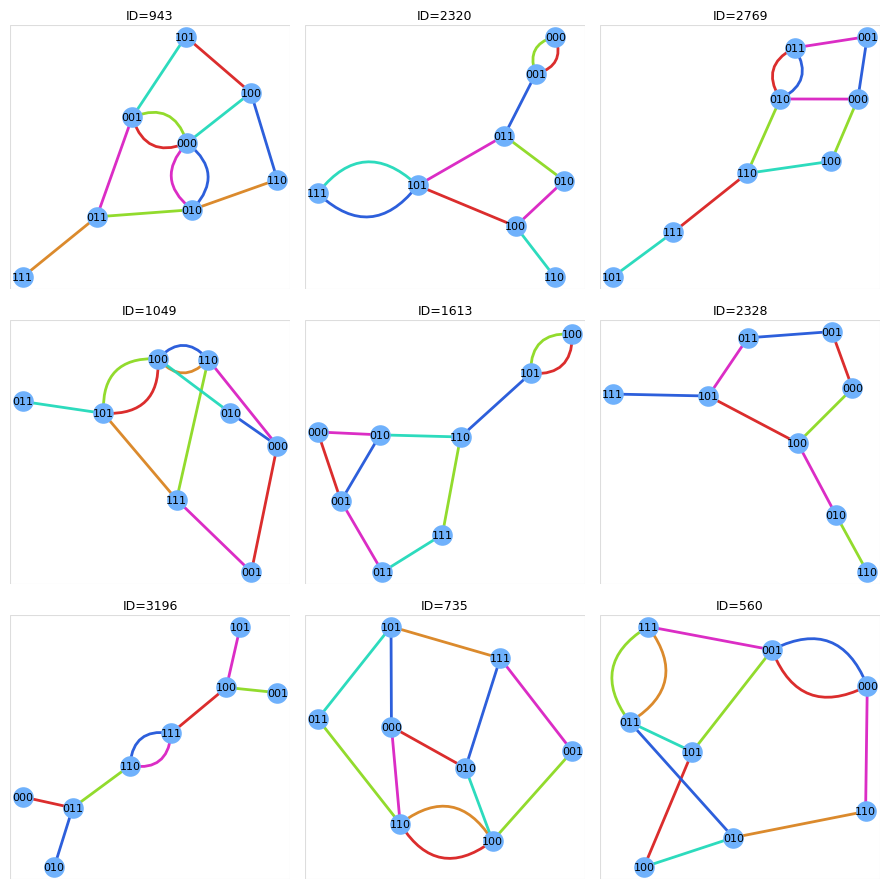

In [5]:
# After you run the main or generate a file:
out_hex = os.path.join("enumeration_graphs", f"{out}.hex.gz")

# A: grid of specific IDs
'''
fig = plot_multiedge_grid_by_ids(
    out_hex_path=out_hex,
    ids=[0,1,2,3,4,5,6,7],
    ncols=4,
    layout="spring",
    sample_nodes=None,       # include all nodes so parallels appear
    with_labels=True,
    label_as_bits=True,     # show 001, 101, ...
    curved_span=0.55,        # clear arc separation
)
plt.show()
'''

# B: random grid (like your previous random plot)
fig = plot_multiedge_grid(
    out_hex_path=out_hex,
    k=9,
    ncols=3,
    select="random",
    layout="spring",
    sample_nodes=None,
    with_labels=True,
    label_as_bits=True,
    show_hex_in_title=False,
    figsize_per_col = 3, 
    figsize_per_row = 3,
)
plt.show()

In [16]:
format(1, f"0{n}b")[::-1]

'100'

## 2-local terms

In [8]:
graph_id = 0
mats = get_pair_mats_by_id(out_hex, graph_id=graph_id)
for k, M in mats.items():
    print(k)
    print(np.array(M))

(0, 1)
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
(0, 2)
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
(1, 2)
[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]


## Save graph

In [11]:
graph_id = 22
filename = "n5_3Dmolecule.json.gz"

parts = get_component_graphs_with_bitlabels_by_id(out_hex, graph_id, relabel="zero_based")
save_parts(parts, filename)

# Draw Graphs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import networkx as nx
from typing import Any, Dict, List, Optional

# --- In-place, button-driven editor with manual bitstring labels ---

class _InplaceGraphEditor:
    def __init__(self, bitwidth=3, node_size=400):
        self.G = nx.Graph()
        self.pos = {}
        self.bitwidth = int(bitwidth)
        self.node_size = node_size

        # UI state
        self.mode = 'move'        # 'add','edge','move','delete','label'
        self.dragging = None
        self.edge_from = None
        self.selected_for_label = None

        # user overrides for labels: node_id -> bitstring
        self.custom_labels = {}

        # persistent figure/axes
        self.fig = plt.figure(figsize=(7.8, 6.4))
        gs = self.fig.add_gridspec(
            nrows=7, ncols=5,
            height_ratios=[20, 1, 1, 1, 1, 1, 1],
            hspace=0.6
        )
        self.ax = self.fig.add_subplot(gs[0, :])
        self.ax.set_aspect('equal', adjustable='datalim')
        self.ax.axis('off')
        self._set_title("move")

        # buttons (kept in same spirit as before)
        self._btn_add    = Button(self.fig.add_subplot(gs[1, 0]), 'Add node')
        self._btn_edge   = Button(self.fig.add_subplot(gs[1, 1]), 'Add edge')
        self._btn_move   = Button(self.fig.add_subplot(gs[1, 2]), 'Move')
        self._btn_delete = Button(self.fig.add_subplot(gs[1, 3]), 'Delete')
        self._btn_export = Button(self.fig.add_subplot(gs[1, 4]), 'Export parts')

        # extra controls
        self._btn_label  = Button(self.fig.add_subplot(gs[2, 0]), 'Edit label')
        # TextBox spans 3 columns for easier typing
        self._tb_ax      = self.fig.add_subplot(gs[2, 1:4])
        self._textbox    = TextBox(self._tb_ax, 'Bits:', initial='', textalignment='left')
        self._btn_apply  = Button(self.fig.add_subplot(gs[2, 4]), 'Apply')

        self._btn_reset  = Button(self.fig.add_subplot(gs[3, 4]), 'Reset')

        # wire buttons
        self._btn_add.on_clicked(lambda e: self._set_mode('add'))
        self._btn_edge.on_clicked(lambda e: self._set_mode('edge'))
        self._btn_move.on_clicked(lambda e: self._set_mode('move'))
        self._btn_delete.on_clicked(lambda e: self._set_mode('delete'))
        self._btn_label.on_clicked(lambda e: self._set_mode('label'))
        self._btn_export.on_clicked(lambda e: self._on_export())
        self._btn_apply.on_clicked(lambda e: self._on_apply_label())
        self._btn_reset.on_clicked(lambda e: self._on_reset())

        # mouse events
        self.fig.canvas.mpl_connect('button_press_event',   self._on_press)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)
        self.fig.canvas.mpl_connect('motion_notify_event',  self._on_motion)

        # artists we update in place
        self.node_sc = None
        self.edge_lines = []
        self.labels = {}

        self.last_parts = None  # set by Export
        self._redraw()          # initial empty canvas

    # ---- helpers ----
    def _default_bits(self, u):  # binary of node id, zero-padded to bitwidth
        return format(u, f"0{self.bitwidth}b")

    def _bits(self, u):
        return self.custom_labels.get(u, self._default_bits(u))

    def _set_title(self, mode, msg=None):
        base = f"Mode = {mode}   (Export parts when done)"
        if msg:
            base += f"   |   {msg}"
        self.ax.set_title(base)

    def _set_mode(self, m):
        self.mode = m
        self.edge_from = None
        self.dragging = None
        self.selected_for_label = None
        # clear and disable TextBox contents when not in 'label'
        if m != 'label':
            self._textbox.set_val('')
        self._set_title(m)
        self.fig.canvas.draw_idle()

    def _on_reset(self):
        self.G.clear()
        self.pos.clear()
        self.custom_labels.clear()
        self.edge_from = None
        self.dragging = None
        self.selected_for_label = None
        self._textbox.set_val('')
        self._redraw()

    def _on_export(self):
        parts = self._to_parts(relabel="zero_based")
        self.last_parts = parts
        self._set_title(self.mode, f"Exported parts ({len(parts)} component(s)) → editor.last_parts")
        self.fig.canvas.draw_idle()
        print("Exported parts → editor.last_parts")
        return parts

    def _add_node(self, xy):
        u = 0
        while u in self.G: u += 1
        self.G.add_node(u)
        self.pos[u] = np.array(xy, dtype=float)
        return u

    def _nearest_node(self, xy, radius=0.05):
        if not self.G.nodes: return None
        pts = np.array([self.pos[u] for u in self.G.nodes])
        d = np.linalg.norm(pts - np.asarray(xy), axis=1)
        i = int(np.argmin(d))
        return list(self.G.nodes)[i] if d[i] <= radius else None

    # ---- label application ----
    def _on_apply_label(self):
        if self.mode != 'label':
            self._set_title(self.mode, "Switch to 'Edit label' to apply.")
            self.fig.canvas.draw_idle()
            return
        if self.selected_for_label is None:
            self._set_title(self.mode, "Click a node to select it for labeling.")
            self.fig.canvas.draw_idle()
            return
        val = self._textbox.text.strip()
        if not all(ch in '01' for ch in val):
            self._set_title(self.mode, "Label must be a bitstring of 0/1.")
            self.fig.canvas.draw_idle()
            return
        if len(val) != self.bitwidth:
            self._set_title(self.mode, f"Label must have length {self.bitwidth}.")
            self.fig.canvas.draw_idle()
            return
        self.custom_labels[self.selected_for_label] = val
        self._set_title(self.mode, f"Set label of node {self.selected_for_label} → {val}")
        # update label artist text
        if self.selected_for_label in self.labels:
            self.labels[self.selected_for_label].set_text(val)
        self.fig.canvas.draw_idle()

    # ---- events ----
    def _on_press(self, event):
        if event.inaxes != self.ax or event.button not in (1, 3) or event.xdata is None:
            return
        xy = (event.xdata, event.ydata)
        u = self._nearest_node(xy)

        if self.mode == 'add':
            if event.button == 1:
                self._add_node(xy); self._redraw()

        elif self.mode == 'edge':
            if event.button == 1:
                if self.edge_from is None:
                    if u is not None:
                        self.edge_from = u
                        self._set_title('edge', f"from {u} → click another node")
                        self.fig.canvas.draw_idle()
                else:
                    if u is not None and u != self.edge_from:
                        a, b = sorted((self.edge_from, u))
                        self.G.add_edge(a, b)
                    self.edge_from = None
                    self._set_title('edge')
                    self._redraw()

        elif self.mode == 'move':
            if event.button == 1 and u is not None:
                self.dragging = u

        elif self.mode == 'delete':
            if event.button == 1 and u is not None:
                self.G.remove_node(u)
                self.pos.pop(u, None)
                self.custom_labels.pop(u, None)
                self._redraw()

        elif self.mode == 'label':
            if event.button == 1:
                if u is not None:
                    self.selected_for_label = u
                    # preload textbox with current label
                    self._textbox.set_val(self._bits(u))
                    self._set_title('label', f"selected node {u} — edit in box, then Apply")
                    self.fig.canvas.draw_idle()

    def _on_release(self, event):
        self.dragging = None

    def _on_motion(self, event):
        if event.inaxes != self.ax or self.mode != 'move' or self.dragging is None:
            return
        if event.xdata is None: return
        self.pos[self.dragging] = np.array([event.xdata, event.ydata], dtype=float)
        self._update_artists_inplace()
        self.fig.canvas.draw_idle()

    # ---- drawing ----
    def _ensure_bounds(self):
        if not self.pos:
            self.ax.set_xlim(-1, 1); self.ax.set_ylim(-1, 1); return
        pts = np.array(list(self.pos.values()))
        xmin, ymin = pts.min(axis=0); xmax, ymax = pts.max(axis=0)
        pad = 0.15 * max(xmax - xmin if xmax>xmin else 1.0,
                         ymax - ymin if ymax>ymin else 1.0)
        self.ax.set_xlim(xmin - pad, xmax + pad)
        self.ax.set_ylim(ymin - pad, ymax + pad)

    def _redraw(self):
        # clear axes, keep widgets
        self.ax.cla()
        self.ax.set_aspect('equal', adjustable='datalim'); self.ax.axis('off')
        self._set_title(self.mode)

        # edges
        self.edge_lines = []
        for (u, v) in self.G.edges():
            (x1, y1) = self.pos[u]; (x2, y2) = self.pos[v]
            ln, = self.ax.plot([x1, x2], [y1, y2], lw=2.0, alpha=0.9)
            self.edge_lines.append((ln, u, v))

        # nodes
        if self.G.number_of_nodes() > 0:
            pts = np.array([self.pos[u] for u in self.G.nodes])
            self.node_sc = self.ax.scatter(pts[:,0], pts[:,1], s=self.node_size, zorder=3)
        else:
            self.node_sc = None

        # labels
        self.labels = {}
        for u in self.G.nodes:
            x, y = self.pos[u]
            txt = self.ax.text(x, y, self._bits(u), ha='center', va='center', fontsize=9, zorder=4)
            self.labels[u] = txt

        self._ensure_bounds()
        self.fig.canvas.draw_idle()

    def _update_artists_inplace(self):
        # edges
        for ln, u, v in self.edge_lines:
            (x1, y1) = self.pos[u]; (x2, y2) = self.pos[v]
            ln.set_data([x1, x2], [y1, y2])
        # nodes
        if self.node_sc is not None and self.G.number_of_nodes() > 0:
            pts = np.array([self.pos[u] for u in self.G.nodes])
            self.node_sc.set_offsets(pts)
        # labels
        for u, txt in self.labels.items():
            x, y = self.pos[u]
            txt.set_position((x, y))
            txt.set_text(self._bits(u))
        self._ensure_bounds()

    # ---- export to `parts` (graph + bitstring labels only) ----
    def _to_parts(self, relabel="zero_based"):
        parts = []
        for comp in nx.connected_components(self.G):
            H = self.G.subgraph(comp).copy()
            if relabel == "zero_based":
                mapping = {u: i for i, u in enumerate(sorted(H.nodes()))}
                H2 = nx.relabel_nodes(H, mapping, copy=True)
                # export **custom** labels if present; else default
                labels = {mapping[u]: self._bits(u) for u in sorted(H.nodes())}
            else:
                H2 = H
                labels = {u: self._bits(u) for u in H.nodes()}
            parts.append({"graph": H2, "labels": labels})
        parts.sort(key=lambda d: (-d["graph"].number_of_nodes(), min(d["graph"].nodes())))
        return parts

def launch_graph_editor(bitwidth=3):
    """
    Same entry point as before (now supports manual label editing):
      • Modes: Add node / Add edge / Move / Delete / Edit label
      • Click a node in 'Edit label' mode, type bits in the text box, click 'Apply'
      • Click 'Export parts' to set:
            editor.last_parts  ->  [{'graph': G_component, 'labels': {node: bitstring}}, ...]
    """
    editor = _InplaceGraphEditor(bitwidth=bitwidth)
    plt.show()
    return editor

import inspect
from typing import Optional

# Keep a reference to any existing implementation
__ORIG_LAUNCH_EDITOR__ = globals().get("launch_graph_editor", None)

def _fn_accepts_kw(fn, name: str) -> bool:
    try:
        sig = inspect.signature(fn)
        return name in sig.parameters
    except Exception:
        return False

def launch_graph_editor(*args, load_path: Optional[str] = None, **kwargs):
    """
    Same interface as before, plus:
      - load_path: optional path to a saved 'parts' file (uses load_parts)

    Behavior:
      - If load_path is provided, parts = load_parts(load_path)
      - If the downstream editor accepts a 'parts' kwarg, it is passed.
      - If not, it is silently dropped to avoid 'unexpected keyword' errors.
    """
    # 1) Resolve target editor to call
    target = __ORIG_LAUNCH_EDITOR__
    if not callable(target):
        # fall back to your concrete editor function if no original launcher exists
        target = globals().get("graph_editor") or globals().get("_graph_editor_inplace")
        if not callable(target):
            raise RuntimeError(
                "No editor found. Define `graph_editor(...)` or `_graph_editor_inplace(...)`, "
                "or define your original `launch_graph_editor` before this wrapper."
            )

    # 2) Compute parts from load_path (if provided)
    loaded_parts = None
    if load_path is not None:
        if "load_parts" not in globals():
            raise RuntimeError("`load_parts(path)` is not defined. Please add your save/load helpers.")
        loaded_parts = load_parts(load_path)

    # 3) Merge with any explicit parts passed in (if the caller provided it)
    explicit_parts = kwargs.pop("parts", None)  # avoid accidental propagation
    merged_parts = explicit_parts if explicit_parts is not None else loaded_parts

    # 4) Only pass 'parts' if the target accepts it
    if merged_parts is not None and _fn_accepts_kw(target, "parts"):
        kwargs["parts"] = merged_parts  # safe to pass
    # else: silently drop; target doesn't support 'parts'

    # 5) Delegate to the editor
    return target(*args, **kwargs)

## Editor

In [8]:
%load_ext ipympl
%matplotlib widget

The ipympl module is not an IPython extension.


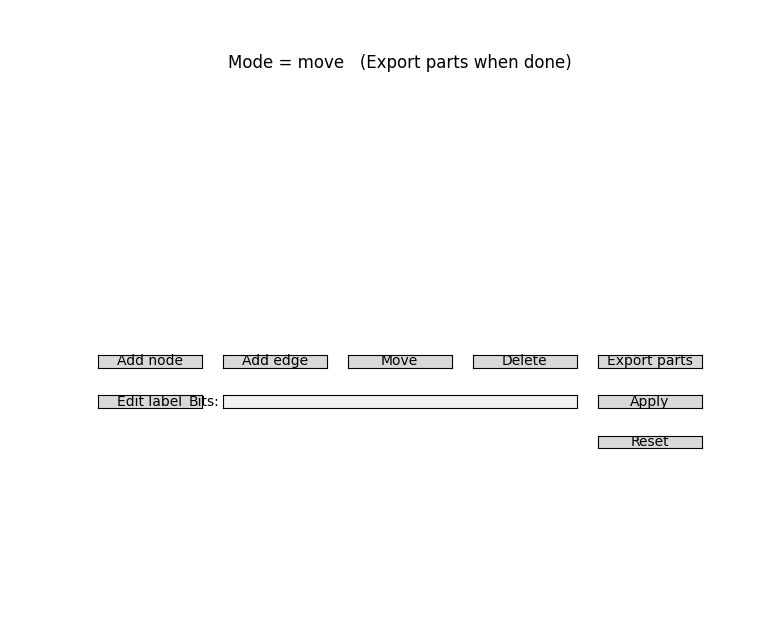

In [10]:
editor = launch_graph_editor(bitwidth=5)

## Save graph

In [46]:
filename = "n4_gray_code_open.json.gz"

# After you get parts from the editor or your pipeline:
save_parts(editor.last_parts, filename)

# Later:
parts = load_parts(filename)
# parts2 has the same structure: [{'graph': nx.Graph, 'labels': {int: '0101'}}, ...]
parts

[{'graph': <networkx.classes.graph.Graph at 0x7f7e60897400>,
  'labels': {0: '000',
   1: '001',
   2: '010',
   3: '011',
   4: '100',
   5: '101',
   6: '110',
   7: '111'}}]

# Interactions

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Any, Dict, Callable, Optional, Tuple
from __future__ import annotations

def _bits_to_zvec(bitstring: str) -> np.ndarray:
    """Map bitstring like '0101' to a vector of Z-eigenvalues (+1 for 0, -1 for 1)."""
    z = np.empty(len(bitstring), dtype=np.float64)
    for i, b in enumerate(bitstring):
        z[i] = 1.0 if b == '0' else -1.0
    return z

def _zvec_from_bits(bits: str) -> np.ndarray:
    """Alias for consistency."""
    return _bits_to_zvec(bits)

def _vech_sym(Fsym: np.ndarray) -> np.ndarray:
    """Upper-triangle (including diagonal) vectorization of a symmetric matrix."""
    n = Fsym.shape[0]
    idx = np.triu_indices(n)
    return Fsym[idx]

def _unvech_to_sym(x: np.ndarray, n: int) -> np.ndarray:
    """Rebuild a symmetric n×n matrix from its upper-triangle vectorization."""
    C = np.zeros((n, n), dtype=np.float64)
    idx = np.triu_indices(n)
    C[idx] = x
    C[(idx[1], idx[0])] = x  # mirror to lower
    return C

def _unpack_part(part: Any):
    """
    Accepts:
      - (G, bitlabels)
      - (G, bitlabels, orig_nodes, mapping)
      - {'G'| 'graph' | 'subgraph', 'bitlabels' | 'labels' | 'node_labels', ...}
    Returns: (G, bitlabels, extras_dict)
    """
    if isinstance(part, dict):
        G = part.get('G') or part.get('graph') or part.get('subgraph')
        bitlabels = part.get('bitlabels') or part.get('labels') or part.get('node_labels')
        extras = {
            'orig_nodes': part.get('orig_nodes'),
            'mapping': part.get('mapping')
        }
        if G is None or bitlabels is None:
            raise ValueError("Part dict must contain at least 'G' (graph) and 'bitlabels'.")
        return G, bitlabels, extras

    if isinstance(part, (tuple, list)):
        if len(part) < 2:
            raise ValueError("Part tuple/list must have at least (G, bitlabels).")
        G = part[0]
        bitlabels = part[1]
        extras = {
            'orig_nodes': part[2] if len(part) >= 3 else None,
            'mapping': part[3] if len(part) >= 4 else None
        }
        return G, bitlabels, extras

    raise TypeError("Unsupported part format; expected dict or tuple/list.")

def _energy_ZZ_sym(u_bits: str, v_bits: str, C: np.ndarray, c0: float = 0.0) -> float:
    """
    E(u,v) = c0 + sum_i C[ii] Z_i^A Z_i^B
                 + sum_{i<j} C[i,j] * (Z_i^A Z_j^B + Z_j^A Z_i^B)/2
    where C is symmetric (n×n).
    """
    zu = _zvec_from_bits(u_bits)
    zv = _zvec_from_bits(v_bits)
    n = len(zu)
    C = np.asarray(C, dtype=float)
    if not np.allclose(C, C.T, atol=1e-12):
        C = 0.5*(C + C.T)

    # diagonal ZZ
    val = float(np.dot(np.diag(C), zu * zv))
    # off-diagonal symmetric ZZ
    for i in range(n):
        for j in range(i+1, n):
            val += float(C[i, j] * 0.5 * (zu[i]*zv[j] + zu[j]*zv[i]))
    return float(c0 + val)


# ---------- NEW: energy with ZZ + single-Z ----------
def _energy_ZZ_Z_sym(u_bits: str, v_bits: str, C: np.ndarray, a: np.ndarray, c0: float = 0.0) -> float:
    """
    E(u,v) = c0
           + sum_i C[ii] Z_i^A Z_i^B
           + sum_{i<j} C[i,j]*(Z_i^A Z_j^B + Z_j^A Z_i^B)/2
           + sum_i a[i] * (Z_i^A + Z_i^B)
    """
    zu = _zvec_from_bits(u_bits)
    zv = _zvec_from_bits(v_bits)
    n = len(zu)
    C = np.asarray(C, dtype=float)
    if not np.allclose(C, C.T, atol=1e-12):
        C = 0.5*(C + C.T)
    a = np.asarray(a, dtype=float)

    # ZZ terms
    val = float(np.dot(np.diag(C), zu * zv))
    for i in range(n):
        for j in range(i+1, n):
            val += float(C[i, j] * 0.5 * (zu[i]*zv[j] + zu[j]*zv[i]))
    # single-Z terms
    val += float(a @ (zu + zv))
    return float(c0 + val)

def _energy_polyZ_sym(
    u_bits: str,
    v_bits: str,
    *,
    C: Optional[np.ndarray] = None,   # ZZ (n x n, symmetric)
    a: Optional[np.ndarray] = None,   # Z  (n,)
    D: Optional[np.ndarray] = None,   # ZZZ tensor with shape (n,n,n_pair) as defined below (see fitter)
    c0: float = 0.0
) -> float:
    """
    Symmetric energy with Z, ZZ, ZZZ terms:
      E = c0
        + sum_i a[i] (Z_i^A + Z_i^B)
        + sum_i C[i,i] Z_i^A Z_i^B
        + sum_{i<j} C[i,j] * (Z_i^A Z_j^B + Z_j^A Z_i^B)/2
        + sum_{i<j} sum_{k not in {i,j}} D[i,j,k] * (Z_i^A Z_j^A Z_k^B + Z_i^B Z_j^B Z_k^A)/2

    Notes:
      • Particle-exchange symmetry is built into the ZZ and ZZZ constructions.
      • For ZZZ we only use *distinct* indices i<j and k≠i,j (repeats collapse to lower order for ±1 eigenvalues).
    """
    zu = _zvec_from_bits(u_bits)
    zv = _zvec_from_bits(v_bits)
    n = len(zu)
    val = c0

    if a is not None:
        a = np.asarray(a, dtype=float)
        val += float(a @ (zu + zv))

    if C is not None:
        C = np.asarray(C, dtype=float)
        if not np.allclose(C, C.T, atol=1e-12):
            C = 0.5 * (C + C.T)
        # diag
        val += float(np.dot(np.diag(C), zu * zv))
        # off-diag symmetric
        for i in range(n):
            for j in range(i+1, n):
                val += float(C[i, j] * 0.5 * (zu[i]*zv[j] + zu[j]*zv[i]))

    if D is not None:
        # D is indexed as D[i, j, k] for i<j and k != i,j
        # contributes 0.5*(Z_i^A Z_j^A Z_k^B + Z_i^B Z_j^B Z_k^A)
        D = np.asarray(D, dtype=float)
        # iterate triples
        for i in range(n):
            for j in range(i+1, n):
                for k in range(n):
                    if k == i or k == j:
                        continue
                    coeff = D[i, j, k]
                    if coeff == 0.0:
                        continue
                    val += float(coeff * 0.5 * (zu[i]*zu[j]*zv[k] + zv[i]*zv[j]*zu[k]))

    return float(val)


def fit_ZZ_for_distance_with_penalty(
    parts: List[Any],
    comp_idx: int,
    V: Dict[int, float] | Callable[[int], float],
    *,
    degrees: Tuple[int, ...] = (1, 2),  # NEW: which k-local Z terms to include; subset of {1,2,3}
    include_bias: bool = True,
    # regularization (separate for each block)
    ridge_Z: float = 1e-8,
    ridge_ZZ: float = 1e-8,
    ridge_ZZZ: float = 1e-8,
    # equal-at-fixed-distance penalty
    lambda_equal: float = 0.0,
    use_unordered_pairs: bool = True,
    include_self_pairs: bool = True,
    ignore_d0: bool = False
) -> Tuple[
    Dict[str, np.ndarray | float | None],  # params: {'a','C','D','c0'}
    Dict[Tuple[int,int], float],            # err_per_pair
    float,                                  # rmse
    Dict[str, Any]                          # extras
]:
    """
    Generalized linear fit for symmetric Z-polynomial energies up to cubic:

      E(u,v) = c0
             + 1∈degrees:  sum_i a[i] (Z_i^A + Z_i^B)
             + 2∈degrees:  sum_i C[i,i] Z_i^A Z_i^B
                           + sum_{i<j} C[i,j] (Z_i^A Z_j^B + Z_j^A Z_i^B)/2
             + 3∈degrees:  sum_{i<j} sum_{k≠i,j} D[i,j,k] (Z_i^A Z_j^A Z_k^B + Z_i^B Z_j^B Z_k^A)/2

    Particle exchange symmetry is enforced by construction.

    Returns:
      params: dict with 'a' (or None), 'C' (or None), 'D' (or None), and 'c0' (float)
    """
    # --- unpack & basics ---
    G, bitlabels, _ = _unpack_part(parts[comp_idx])
    nodes = sorted(G.nodes())
    sp = dict(nx.all_pairs_shortest_path_length(G))
    n = len(bitlabels[nodes[0]])
    for u in nodes:
        if len(bitlabels[u]) != n:
            raise ValueError("All bitstrings in this component must have the same length.")
    zvecs = {u: _bits_to_zvec(bitlabels[u]) for u in nodes}

    use_Z   = (1 in degrees)
    use_ZZ  = (2 in degrees)
    use_ZZZ = (3 in degrees)

    # --- supervised pairs (target = V(dist)) ---
    pairs: List[Tuple[int,int]] = []
    y_list: List[float] = []

    def V_of(d: int) -> float:
        return float(V(d)) if callable(V) else float(V.get(d, 0.0))

    if use_unordered_pairs:
        for i, u in enumerate(nodes):
            start_j = i if include_self_pairs else i+1
            for v in nodes[start_j:]:
                d = sp[u][v]
                if ignore_d0 and d == 0:
                    continue
                pairs.append((u, v))
                y_list.append(V_of(d))
    else:
        for u in nodes:
            for v in nodes:
                if (u == v) and (not include_self_pairs):
                    continue
                d = sp[u][v]
                if ignore_d0 and d == 0:
                    continue
                pairs.append((u, v))
                y_list.append(V_of(d))

    if not pairs:
        raise ValueError("No supervised pairs after filtering (maybe all d==0 and ignore_d0=True).")
    y = np.asarray(y_list, dtype=np.float64)

    # --- feature layout & sizes ---
    # Z block
    pZ = n if use_Z else 0
    # ZZ block
    pZZ = 0
    if use_ZZ:
        pZZ = n*(n+1)//2  # vech(C_sym)
    # ZZZ block: parameters D[i,j,k] for i<j, k != i,j
    pZZZ = 0
    if use_ZZZ:
        pZZZ = (n*(n-1)//2) * (n-2) if n >= 3 else 0

    bias_cols = 1 if include_bias else 0
    Dcols = pZ + pZZ + pZZZ + bias_cols

    # index helpers to place columns
    off_Z_start  = 0
    off_ZZ_start = off_Z_start + pZ
    off_ZZZ_start = off_ZZ_start + pZZ
    off_b_start  = off_ZZZ_start + pZZZ

    # --- builders for rows ---
    # Z: (Z(u)+Z(v))
    def feat_Z(u: int, v: int) -> np.ndarray:
        if not use_Z: return np.zeros(0, dtype=np.float64)
        return zvecs[u] + zvecs[v]

    # ZZ: vech of 0.5*(zu zv^T + zv zu^T)
    def feat_ZZ(u: int, v: int) -> np.ndarray:
        if not use_ZZ: return np.zeros(0, dtype=np.float64)
        zu = zvecs[u]; zv = zvecs[v]
        Fsym = 0.5 * (np.outer(zu, zv) + np.outer(zv, zu))
        return _vech_sym(Fsym)

    # ZZZ: column order is lex over (i<j), then k increasing, skipping k in {i,j}
    # value = 0.5*(zu[i]zu[j]zv[k] + zv[i]zv[j]zu[k])
    ij_list = []
    if use_ZZZ and n >= 3:
        for i in range(n):
            for j in range(i+1, n):
                for k in range(n):
                    if k == i or k == j:
                        continue
                    ij_list.append((i, j, k))  # mapping to column index

    def feat_ZZZ(u: int, v: int) -> np.ndarray:
        if not use_ZZZ or n < 3:
            return np.zeros(0, dtype=np.float64)
        zu = zvecs[u]; zv = zvecs[v]
        f = np.empty(len(ij_list), dtype=np.float64)
        for idx, (i, j, k) in enumerate(ij_list):
            f[idx] = 0.5 * (zu[i]*zu[j]*zv[k] + zv[i]*zv[j]*zu[k])
        return f

    # --- assemble supervised design matrix ---
    A_sup = np.zeros((len(pairs), Dcols), dtype=np.float64)
    for r, (u, v) in enumerate(pairs):
        c = off_Z_start
        if use_Z:
            zrow = feat_Z(u, v)
            A_sup[r, c:c+pZ] = zrow
            c += pZ
        if use_ZZ:
            zzrow = feat_ZZ(u, v)
            A_sup[r, c:c+pZZ] = zzrow
            c += pZZ
        if use_ZZZ:
            zzzrow = feat_ZZZ(u, v)
            A_sup[r, c:c+pZZZ] = zzzrow
            c += pZZZ
        if include_bias:
            A_sup[r, off_b_start] = 1.0

    # --- equal-within-distance penalty rows (anchor differences) ---
    A_pen = None
    b_pen = None
    if lambda_equal > 0.0:
        pen_rows: List[np.ndarray] = []
        for u in nodes:
            by_d: Dict[int, List[int]] = {}
            for w in nodes:
                d = sp[u][w]
                if ignore_d0 and d == 0:
                    continue
                by_d.setdefault(d, []).append(w)
            for d, ws in by_d.items():
                if len(ws) < 2:
                    continue
                w0 = ws[0]
                # build features for anchor
                base = np.zeros(Dcols, dtype=np.float64)
                c = off_Z_start
                if use_Z:
                    base[c:c+pZ] = feat_Z(u, w0); c += pZ
                if use_ZZ:
                    base[c:c+pZZ] = feat_ZZ(u, w0); c += pZZ
                if use_ZZZ:
                    base[c:c+pZZZ] = feat_ZZZ(u, w0); c += pZZZ
                # bias cancels in differences
                for w in ws[1:]:
                    row = np.zeros(Dcols, dtype=np.float64)
                    c = off_Z_start
                    if use_Z:
                        row[c:c+pZ] = feat_Z(u, w); c += pZ
                    if use_ZZ:
                        row[c:c+pZZ] = feat_ZZ(u, w); c += pZZ
                    if use_ZZZ:
                        row[c:c+pZZZ] = feat_ZZZ(u, w); c += pZZZ
                    pen_rows.append(row - base)
        if pen_rows:
            A_pen = np.vstack(pen_rows)
            b_pen = np.zeros(A_pen.shape[0], dtype=np.float64)
            A_pen *= math.sqrt(lambda_equal)

    # --- solve regularized normal equations (block-diagonal ridge) ---
    if A_pen is not None:
        A = np.vstack([A_sup, A_pen])
        b = np.concatenate([y, b_pen])
    else:
        A, b = A_sup, y

    R = np.zeros((Dcols, Dcols), dtype=np.float64)
    if use_Z   and ridge_Z   > 0: R[off_Z_start:off_Z_start+pZ,                 off_Z_start:off_Z_start+pZ]                   = ridge_Z   * np.eye(pZ)
    if use_ZZ  and ridge_ZZ  > 0: R[off_ZZ_start:off_ZZ_start+pZZ,             off_ZZ_start:off_ZZ_start+pZZ]                 = ridge_ZZ  * np.eye(pZZ)
    if use_ZZZ and ridge_ZZZ > 0: R[off_ZZZ_start:off_ZZZ_start+pZZZ,           off_ZZZ_start:off_ZZZ_start+pZZZ]              = ridge_ZZZ * np.eye(pZZZ)
    # no ridge on bias

    AtA = A.T @ A + R
    Atb = A.T @ b
    sol = np.linalg.solve(AtA, Atb)

    # --- unpack solution into params dict ---
    params: Dict[str, np.ndarray | float | None] = {"a": None, "C": None, "D": None, "c0": 0.0}
    ptr = 0
    if use_Z:
        a = sol[ptr:ptr+pZ].copy(); ptr += pZ
        params["a"] = a
    if use_ZZ:
        xC = sol[ptr:ptr+pZZ].copy(); ptr += pZZ
        C = _unvech_to_sym(xC, n)
        params["C"] = C
    if use_ZZZ:
        xD = sol[ptr:ptr+pZZZ].copy(); ptr += pZZZ
        # store in dense tensor D[i,j,k] with i<j; fill zeros elsewhere
        Dten = np.zeros((n, n, n), dtype=np.float64)
        t = 0
        for i in range(n):
            for j in range(i+1, n):
                for k in range(n):
                    if k == i or k == j:
                        continue
                    Dten[i, j, k] = xD[t]; t += 1
        params["D"] = Dten
    if include_bias:
        params["c0"] = float(sol[ptr])

    # errors on supervised rows only
    yhat_sup = A_sup @ sol
    resid = yhat_sup - y
    err_per_pair: Dict[Tuple[int,int], float] = {}
    if use_unordered_pairs:
        for r, (u, v) in enumerate(pairs):
            err_per_pair[(min(u, v), max(u, v))] = float(resid[r]**2)
    else:
        for r, (u, v) in enumerate(pairs):
            err_per_pair[(u, v)] = float(resid[r]**2)
    rmse = float(np.sqrt(np.mean(resid**2)))

    extras = {'nodes': nodes, 'n': n, 'degrees': tuple(sorted(degrees))}
    return params, err_per_pair, rmse, extras

def plot_interaction_by_distance_panels(
    parts, comp_idx: int,
    C=None, c0: float = 0.0,
    *, a: Optional[np.ndarray] = None, D: Optional[np.ndarray] = None,   # NEW: ZZZ tensor
    annotate: bool = True, jitter: float = 0.08,
    ncols: int = 4, figsize_per_col: float = 2.5, figsize_per_row: float = 2.5,
    include_center: bool = True,
    V: Optional[Dict[int, float] | Callable[[int], float]] = None,
    V_marker: str = "o", V_linestyle: str = "-", V_alpha: float = 0.9
):
    """
    Panels per node; x = graph distance, y = model energy using poly-Z params (Z/ZZ/ZZZ).
    Backward compatible: if D is None and a is None, it reduces to your prior ZZ plot.
    """
    entry = parts[comp_idx]
    if isinstance(entry, dict):
        G = entry["graph"]; bitlabels = entry["labels"]
    else:
        G, bitlabels = entry[0], entry[1]

    assert nx.is_connected(G), "Selected component must be connected."
    any_bits = next(iter(bitlabels.values())); n = len(any_bits); N = G.number_of_nodes()

    # Cast/validate shapes
    C_arr = None
    if C is not None:
        C_arr = np.asarray(C, dtype=float)
        assert C_arr.shape == (n, n), f"C must be {n}x{n}"
        if not np.allclose(C_arr, C_arr.T, atol=1e-12):
            C_arr = 0.5*(C_arr + C_arr.T)

    a_arr = None
    if a is not None:
        a_arr = np.asarray(a, dtype=float)
        assert a_arr.shape == (n,), f"a must be shape ({n},)"

    D_arr = None
    if D is not None:
        D_arr = np.asarray(D, dtype=float)
        assert D_arr.shape == (n, n, n), f"D must be shape ({n},{n},{n})"

    dist = dict(nx.all_pairs_shortest_path_length(G))
    nodes = sorted(G.nodes())

    all_dists = set([0])
    for u in nodes:
        for v in nodes:
            all_dists.add(dist[u][v])
    xticks = sorted(all_dists)

    ncols = max(1, int(ncols))
    nrows = (N + ncols - 1) // ncols
    fig_w = max(6.0, figsize_per_col * ncols)
    fig_h = max(4.0, figsize_per_row * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes = axes.ravel()
    rng = np.random.default_rng(0)

    def V_of(d: int) -> float:
        if V is None: return np.nan
        return float(V(d) if callable(V) else V.get(d, np.nan))

    V_x = xticks
    V_y = [V_of(d) for d in V_x] if V is not None else None

    for idx, u in enumerate(nodes):
        ax = axes[idx]; u_bits = bitlabels[u]
        xs, ys, labels = [], [], []

        if include_center:
            e0 = _energy_polyZ_sym(u_bits, u_bits, C=C_arr, a=a_arr, D=D_arr, c0=c0)
            xs.append(0.0 + float(rng.normal(0.0, jitter))); ys.append(e0); labels.append(u_bits)

        for v in nodes:
            if not include_center and v == u:  # skip self if not including center
                continue
            if include_center and v == u:
                continue
            d = dist[u][v]
            x = d + float(rng.normal(0.0, jitter))
            y = _energy_polyZ_sym(u_bits, bitlabels[v], C=C_arr, a=a_arr, D=D_arr, c0=c0)
            xs.append(x); ys.append(y); labels.append(bitlabels[v])

        label_model = "poly-Z (Z/ZZ/ZZZ as given)"
        ax.scatter(xs, ys, s=26, alpha=0.85, label=label_model)

        if V_y is not None:
            ax.plot(V_x, V_y, linestyle=V_linestyle, marker=V_marker, alpha=V_alpha, label="V(d)")

        if annotate:
            for (x, y, lab) in zip(xs, ys, labels):
                ax.text(x, y, lab, fontsize=7, ha='center', va='bottom')

        ax.set_title(f"center = {u_bits}", fontsize=9, pad=4)
        ax.set_xticks(xticks)
        ax.set_xlim(min(xticks) - 0.6, max(xticks) + 0.6)
        ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.7)
        ax.set_xlabel("graph distance", fontsize=8)
        ax.set_ylabel("E (poly-Z model)", fontsize=8)

        y_all = ys[:]
        if V_y is not None:
            y_all.extend([v for v in V_y if np.isfinite(v)])
        if y_all:
            ypad = 0.05 * (max(y_all) - min(y_all) + 1e-12)
            ax.set_ylim(min(y_all) - ypad, max(y_all) + ypad)

        if idx == 0 and (V_y is not None):
            ax.legend(fontsize=8, loc="best", framealpha=0.3)

        for spine in ax.spines.values():
            spine.set_alpha(0.25)

    for j in range(N, nrows * ncols):
        axes[j].set_visible(False)

    plt.tight_layout()
    return fig, axes

/home/jchen9/pauli_first_quantization/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


## Optimization

[{'graph': <networkx.classes.graph.Graph object at 0x7feab9641f70>, 'labels': {0: '00000', 1: '00001', 2: '00010', 3: '00011', 4: '00100', 5: '00101', 6: '00110', 7: '00111', 8: '01000', 9: '01001', 10: '01010', 11: '01011', 12: '01100', 13: '01101', 14: '01110', 15: '01111', 16: '10000', 17: '10001', 18: '10010', 19: '10011', 20: '10100', 21: '10101', 22: '10110', 23: '10111', 24: '11000', 25: '11001', 26: '11010', 27: '11011', 28: '11100', 29: '11101', 30: '11110', 31: '11111'}}]


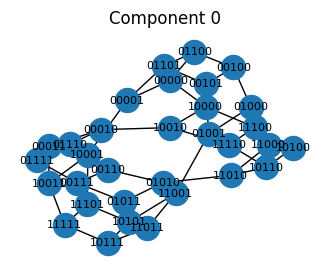

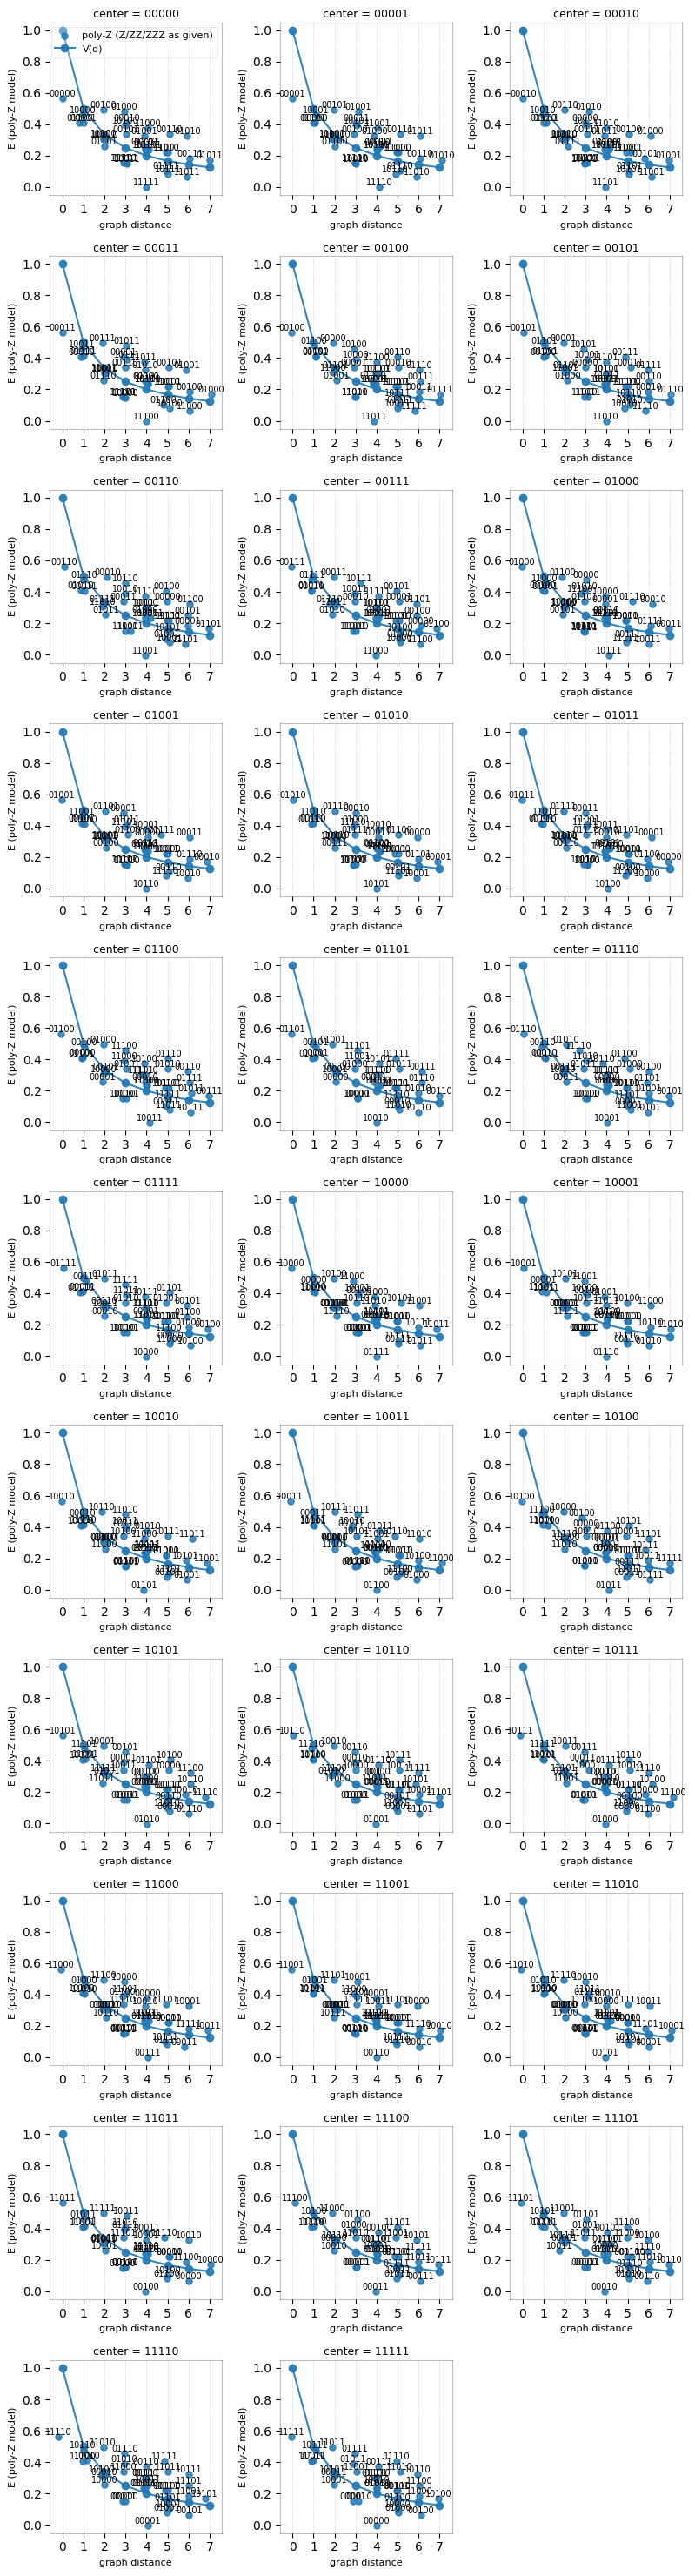

In [ ]:
#graph_id = 218
#parts = get_component_graphs_with_bitlabels_by_id(out_hex, graph_id, relabel="zero_based")

#parts = editor.last_parts

parts = load_parts("individual_graphs/n5_2D_lattice.json.gz")

print(parts)
for i, comp in enumerate(parts):
    H, labels = comp["graph"], comp["labels"]
    pos = nx.spring_layout(H, seed=0)
    plt.figure(figsize=(4,3))
    nx.draw_networkx(H, pos, labels=labels, node_size=300, font_size=8)
    plt.title(f"Component {i}")
    plt.axis('off'); plt.show()
    
comp_idx = 0

# Suppose you already have parts = [(G0, labels0), (G1, labels1), ...]
# where labelsX: node_id -> bitstring (length n, consistent in that component).

# Example distance potential: decays with graph distance (cutoff at 3)
def V_of_d(d):
    #return 1 if d == 0 else 0
    return 1/(d + 1)
    #return 4-d if d <= 4 else 0

params, _, _, _ = fit_ZZ_for_distance_with_penalty(parts, 
                                                   comp_idx, 
                                                   V_of_d, 
                                                   degrees=(2,),
                                                   lambda_equal = 0)

C=params["C"]
c0=params["c0"]
a=params["a"]
D=params["D"]

# Plot panels (pass 'a' to use ZZ+Z; omit 'a' to view ZZ-only)
fig, axes = plot_interaction_by_distance_panels(
    parts, comp_idx=0, C=C, a=a, c0=c0,D=D,
    include_center=True,
    V=V_of_d,
    ncols=3, 
    figsize_per_col = 2.7, 
    figsize_per_row = 2.7,
)